# Brazilian E-Commerce Public Dataset by Olist

# 1. Introduccion EDA

**Este notebook contiene la exploración inicial y el analisis del conjunto de datos**.


En esta fase se comprende la estructura de los datos,identifica posibles problemas de calidad,analiza la distribución de las variables y detecta posibles inconsistencias que puedan afectar en las siguientes etapas.

Este análisis permite definir estrategias adecuadas de limpieza y preparación de los datos.
* Fuente del conjunto de datos: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_order_items_dataset.csv


# 2.Librerias

En esta sección se importan las librerias a utilizar para el análisis y manipulación de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 3.Cargando datasets

En esta sección cargamos todos los archivos CSV que componen el conjunto de datos de comercio electrónico de Olist.

Cada archivo representa una tabla diferente dentro del sistema de ventas,en donde se incluye la informacion sobre:

*   pedidos
*   clientes
*   productos
*   pagos
*   reseñas
*   vendedores

Estos dataset se integrarán para luego relizar análisis mas completos del comportamiento de las ventas y del proceso de entraga



In [ ]:
customers = pd.read_csv('/content/drive/MyDrive/Invers/olist_customers_dataset.csv')
orders = pd.read_csv('/content/drive/MyDrive/Invers/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Invers/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/Invers/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/Invers/olist_order_reviews_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/Invers/olist_products_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/Invers/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/Invers/olist_geolocation_dataset.csv')
categories = pd.read_csv('/content/drive/MyDrive/Invers/product_category_name_translation.csv')

# 4.Dimensiones de cada tabla

Este análisis de dimensiones permite comprenter el volumen de informacion disponible y detectar posibles desbalances entre las diferentes tablas.

Esto nos permite saber cuales prodrian requerir mayor procesamiento durante el análisis.

In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "categories": categories
}

In [ ]:
for name, df in datasets.items():
  print("---->", name)
  print(df.shape)
  print()

----> customers
(99441, 5)

----> orders
(99441, 8)

----> order_items
(112650, 7)

----> payments
(103886, 5)

----> reviews
(99224, 7)

----> products
(32951, 9)

----> sellers
(3095, 4)

----> geolocation
(1000163, 5)

----> categories
(71, 2)



**Observación**:

Se puede apreciar que los datasets presentan diferentes tamaños en cuanto a número de registros.

El data set **orders** contiene una gran cantidad de registros, lo cual indicaria que es una de las tablas principales del sistema de ventas.Lo que no sucede con **products** y **sellers** que contienen menos registros, ya que presentan información más especifica.

Con esto podemos deducir que algunas tablas funcionan como **transaccionales** y otras como tablas de **referencia**

# 5.Exploración de columnas

En esta sección se examina las columnas presentes en cada dataset con el objetivo de comprender la estructura de los datos y el significado de cada variable.

Esto nos permite identificar:
  * Variables categoricas
  * Variables numéricas
  * Variables de fecha
  * posibles inconsistencias en los nombres de columnas

In [ ]:
for name, df in datasets.items():
  print("---->", name)
  print(df.columns)
  print()

----> customers
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

----> orders
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

----> order_items
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

----> payments
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

----> reviews
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

----> products
Index(['product_id', 'product_category_name', 'product_name_lenght',
       '

**Observación**:

Existen algunas inconsistencias de nomeclatura y errores ortográficos en los nombres de las columnas como :
  * En la tabla products, hay una mezcla de ortografía correcta e incorrecta: **product_name_lenght** y **product_description_lenght**, el correcto product_length_cm(termina en"th").
  * Hay una falta de estandarización en los sufijos itilizados para fecha u hora,se las identifica en las tablas **orders** y **reviews** en donde se utiliza los sufijos: **timestamp**,**at**,**date**.Lo ideal es usar solo un estándar.

# 6.Primera vista a los datos

En esta parte podemos observar y analizar los diferentes tipos de datos en sus repectivas tablas.

Esto nos ayudara al momento de analizar que los tipos de datos esten guardados correctamente

In [ ]:
for name, df in datasets.items():
  print("---->", name)
  print(df.head())
  print()

----> customers
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

----> orders
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb62512

# 7.Tipos de datos



Esta parte nos permite verificar si cada columna posee el tipo de dato adecuado para su análisis y detectar los errores que pueden afectar cálculos estadisticos, temporales o visualizaciones.

In [ ]:
for name, df in datasets.items():
  print("---->", name)
  print(df.dtypes)
  print()

----> customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

----> orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

----> order_items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

----> payments
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

----> 

**Observaciones**:

Se identifico que la mayoría de columnas poseen tipos de datos adecuados para su contenido.Sin embargo, algunas columnas presentan fechas como tipo **object**, por lo que se devera convertirlas a tipo **datetime** para el análisis temporal como tiempos de entraga, duración de pedidos y análisis por fechas.


# 8.Valores nulos

En esta parte se analiza la presencia de valores nulos o faltantes en los diferentes dataset.


In [ ]:
for name, df in datasets.items():
    print("---->", name)
    print(df.isnull().sum())
    print()

----> customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

----> orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

----> order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

----> payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

----> reviews
review_id                      0
order_id                       0
review_score                   0
review_com

**Observaciones** :

Los siguientes datasets contienen valores nulos:
- orders
- reviews
- products

# 9.Grafico de barras para valores nulos
Las siguientes graficas muestran el numero total de valores existentes presentes en cada una de las columnas de los diferentes datasets.Este analisis permite identificar la cantidad de datos faltantes y evaluar las mejores opciones durante el proceso de limpieza de datos.

- En caso de ser necesario , se puede aplicar un método de imputación para completar la inforación faltante
- Tomar en concideracion que si una comlumna presenta una gran cantidad de valores nulos , esto indica una falta significatica de información y reduce la calidad de los datos generando sesgos en el análisis estadisticos.




 ----> customers 



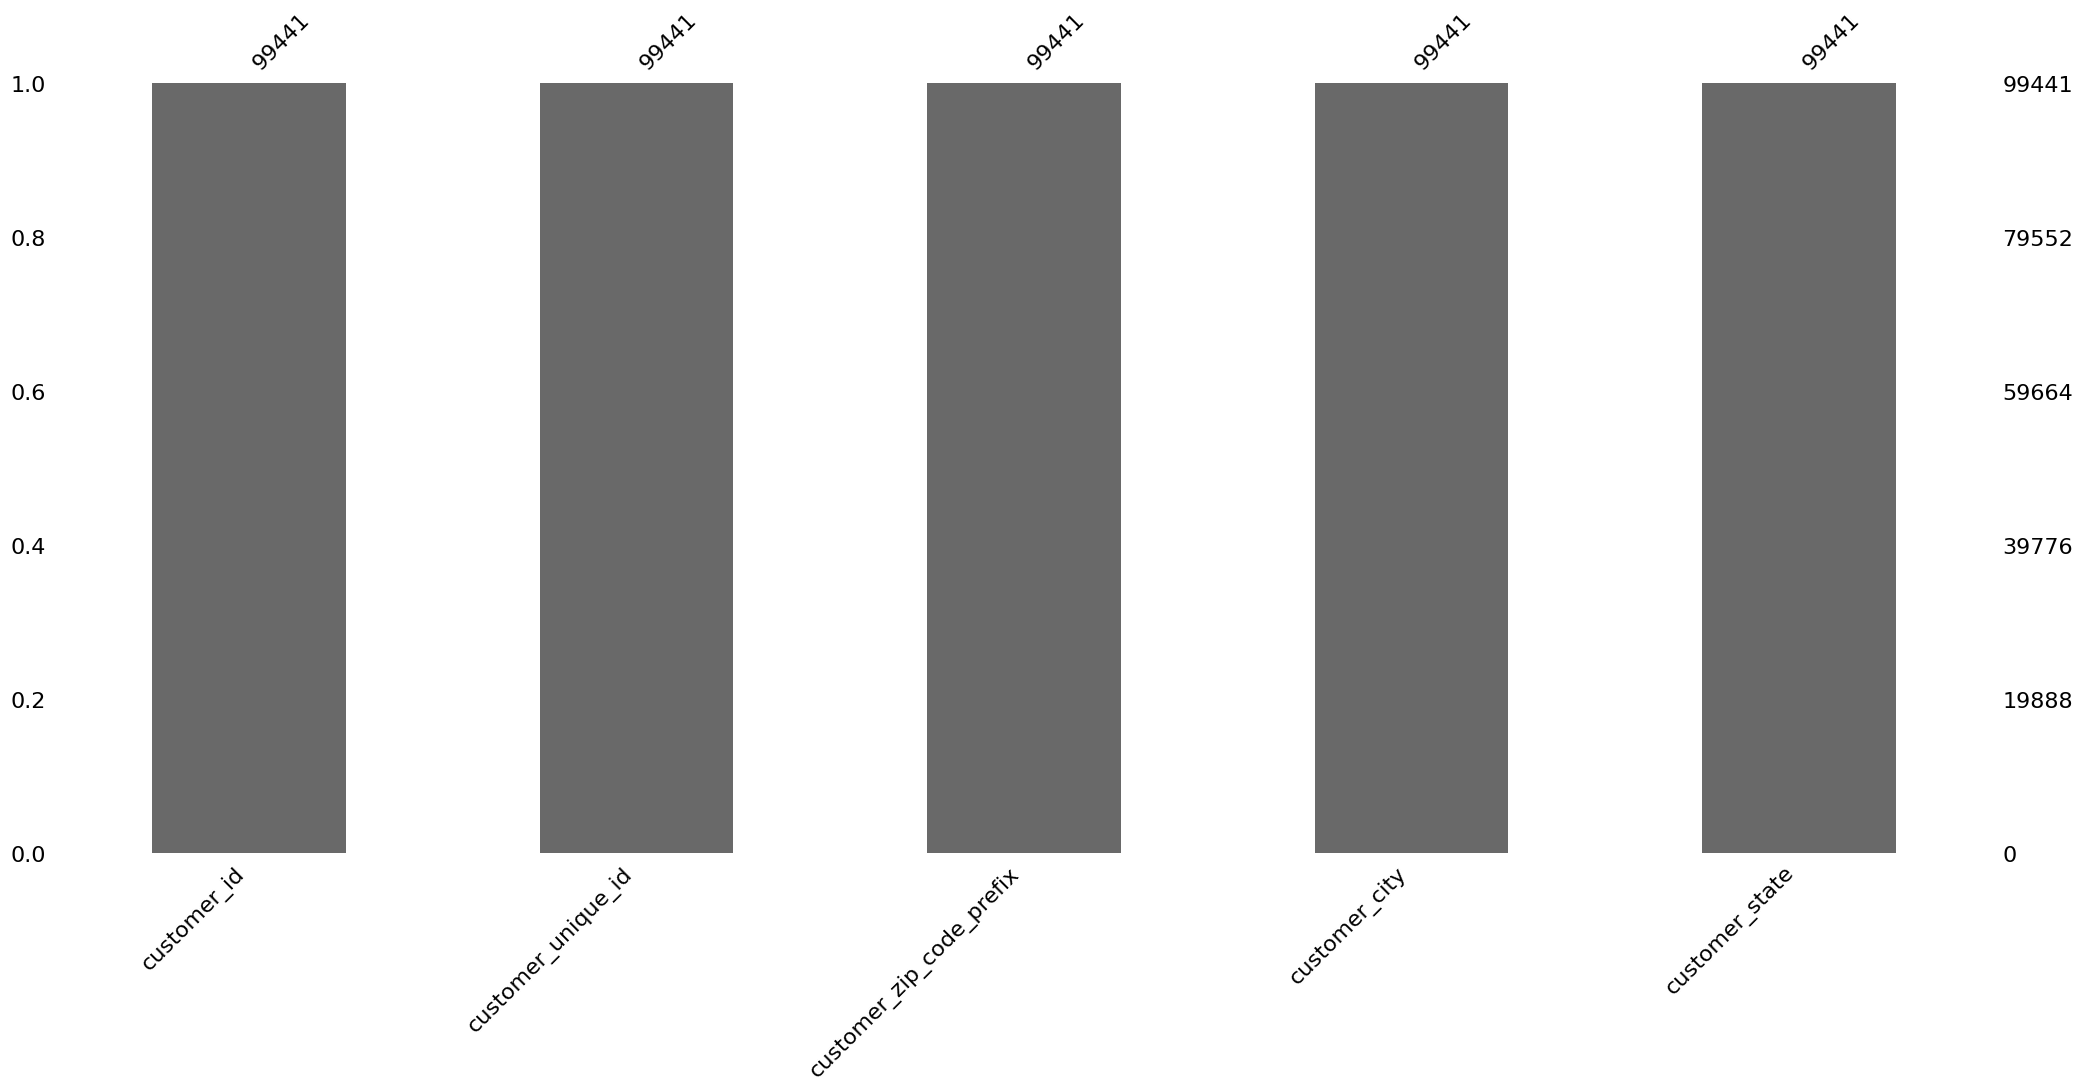


 ----> orders 



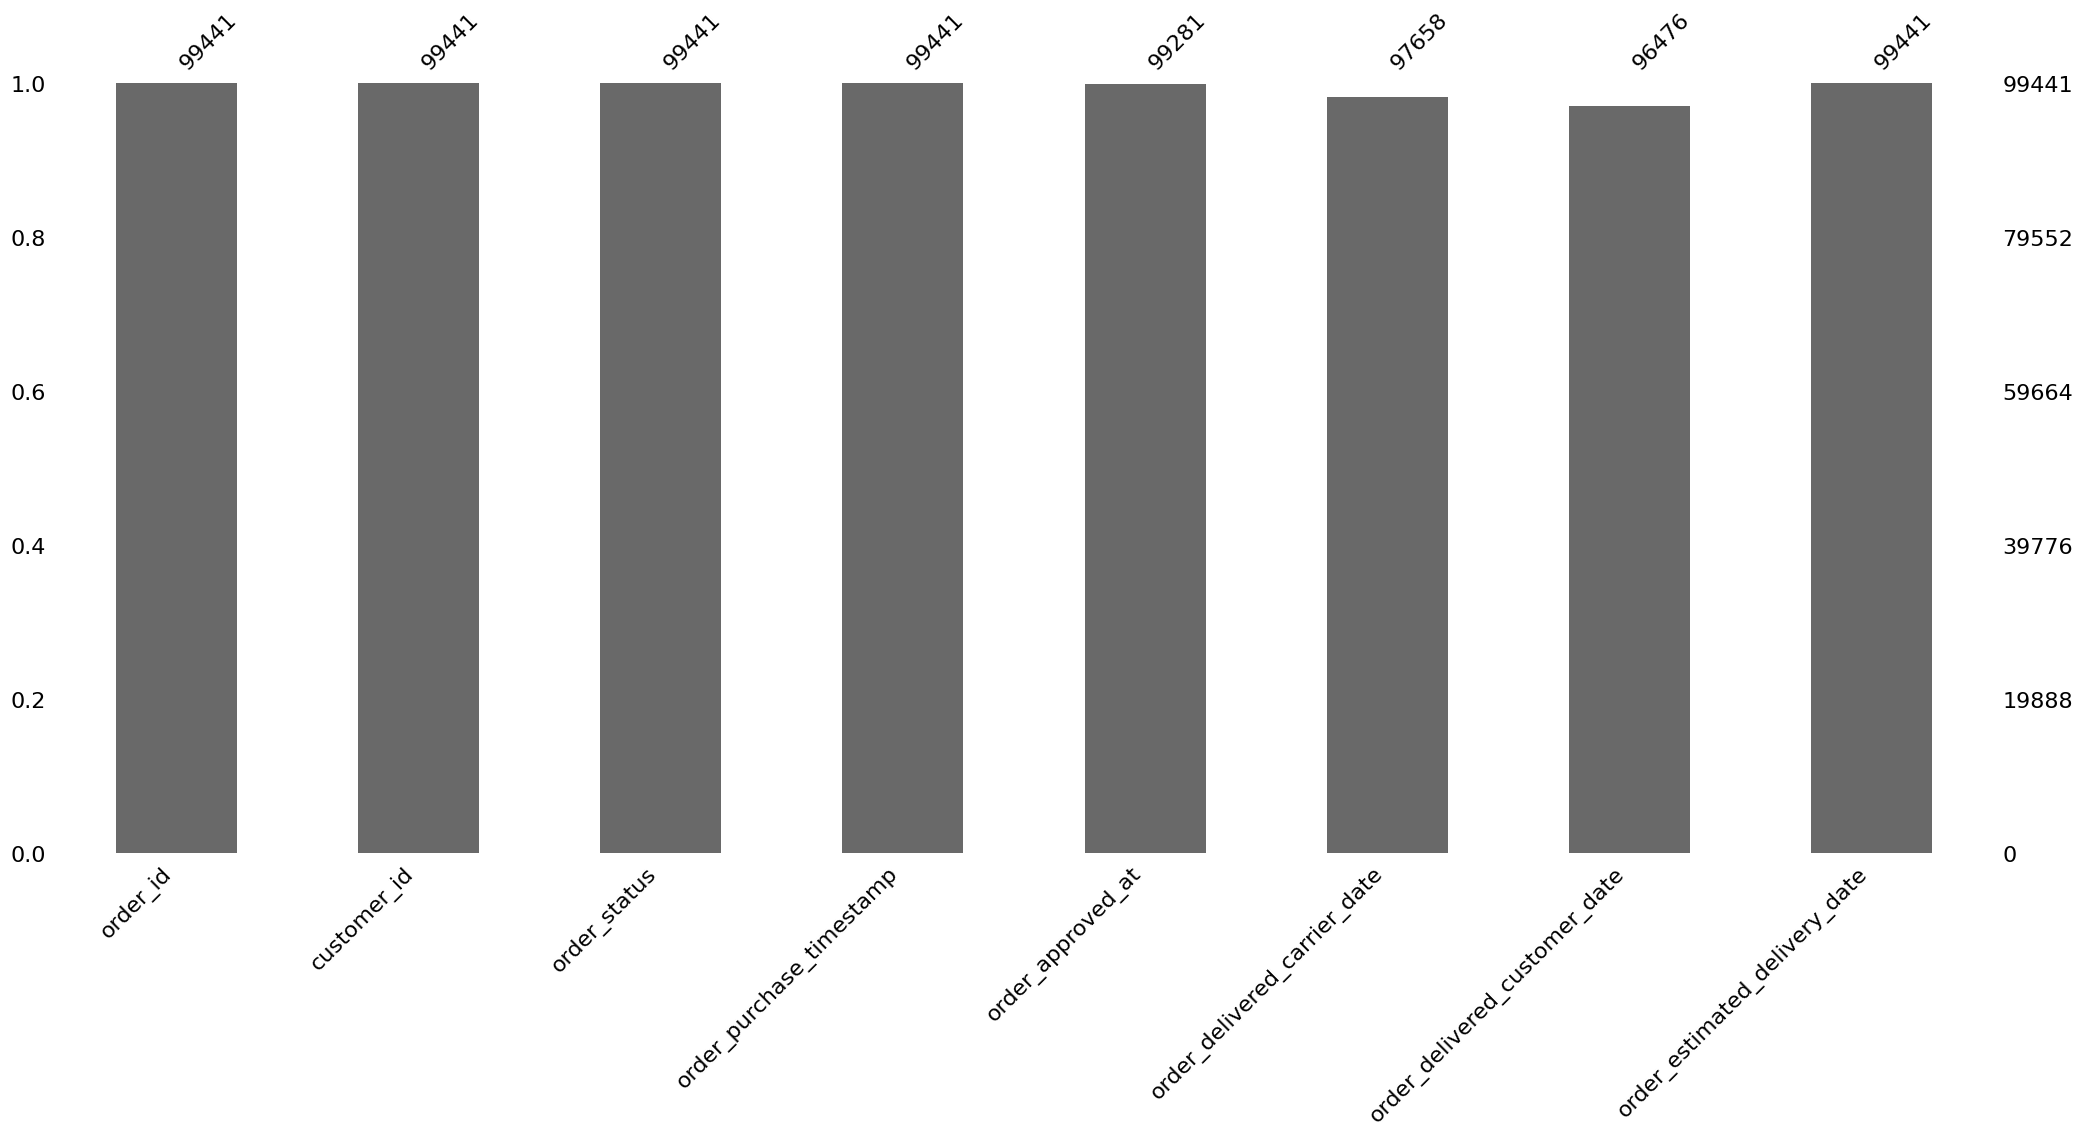


 ----> order_items 



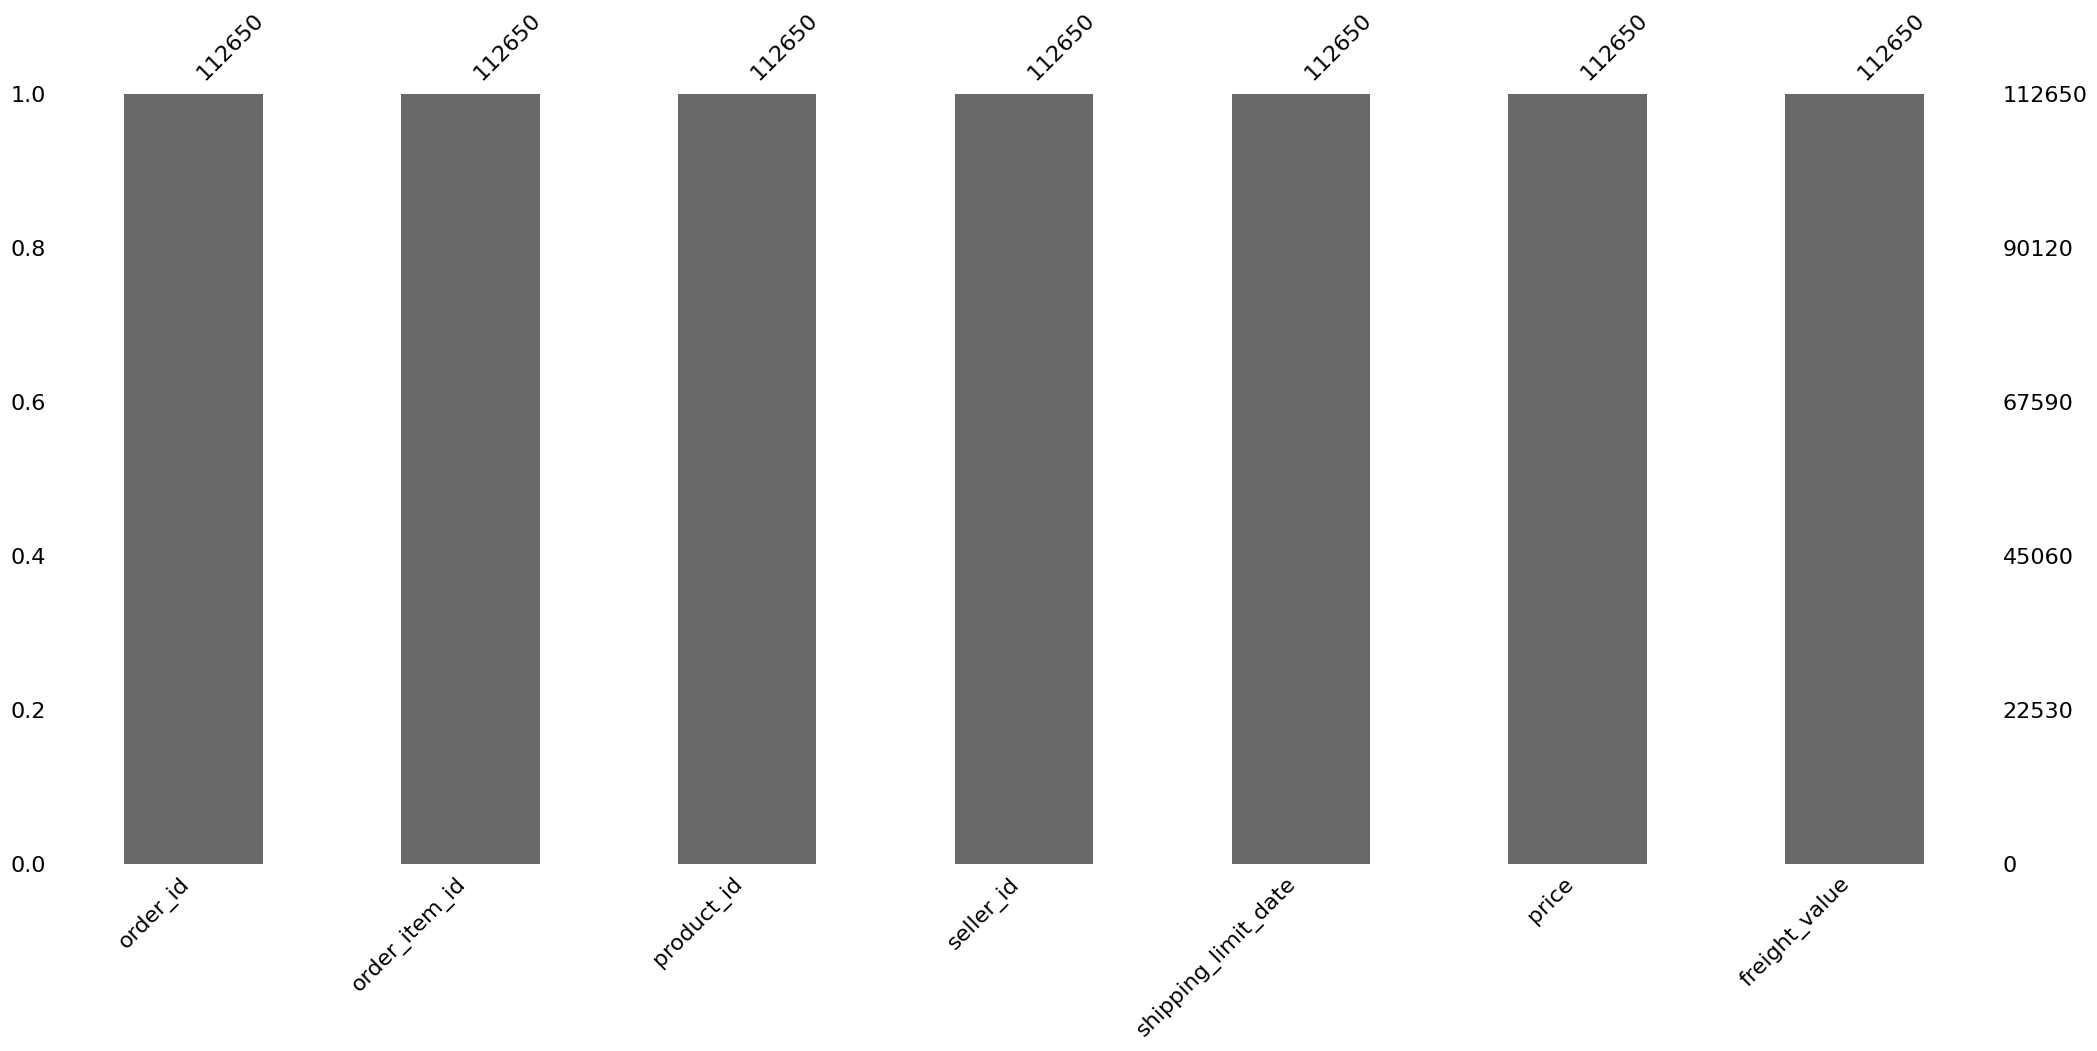


 ----> payments 



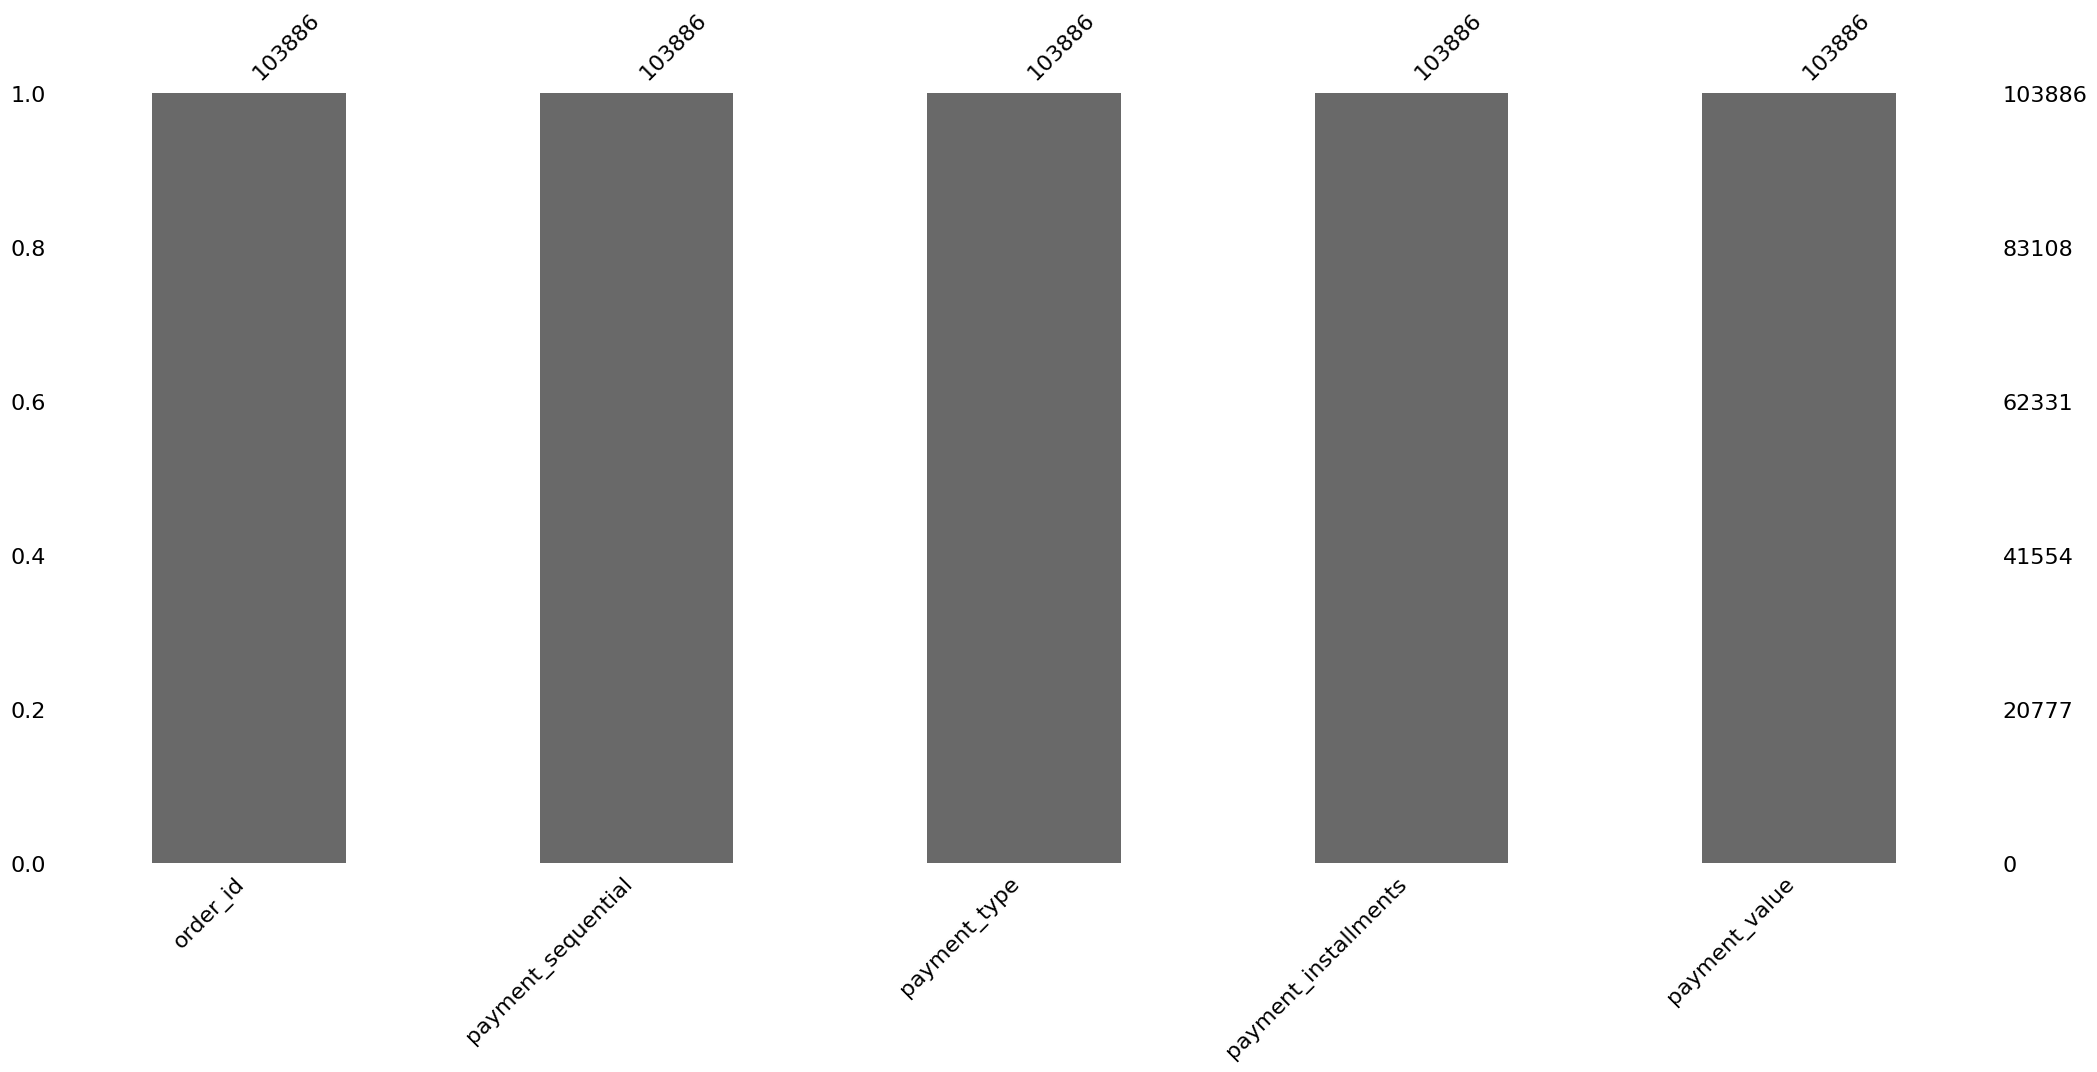


 ----> reviews 



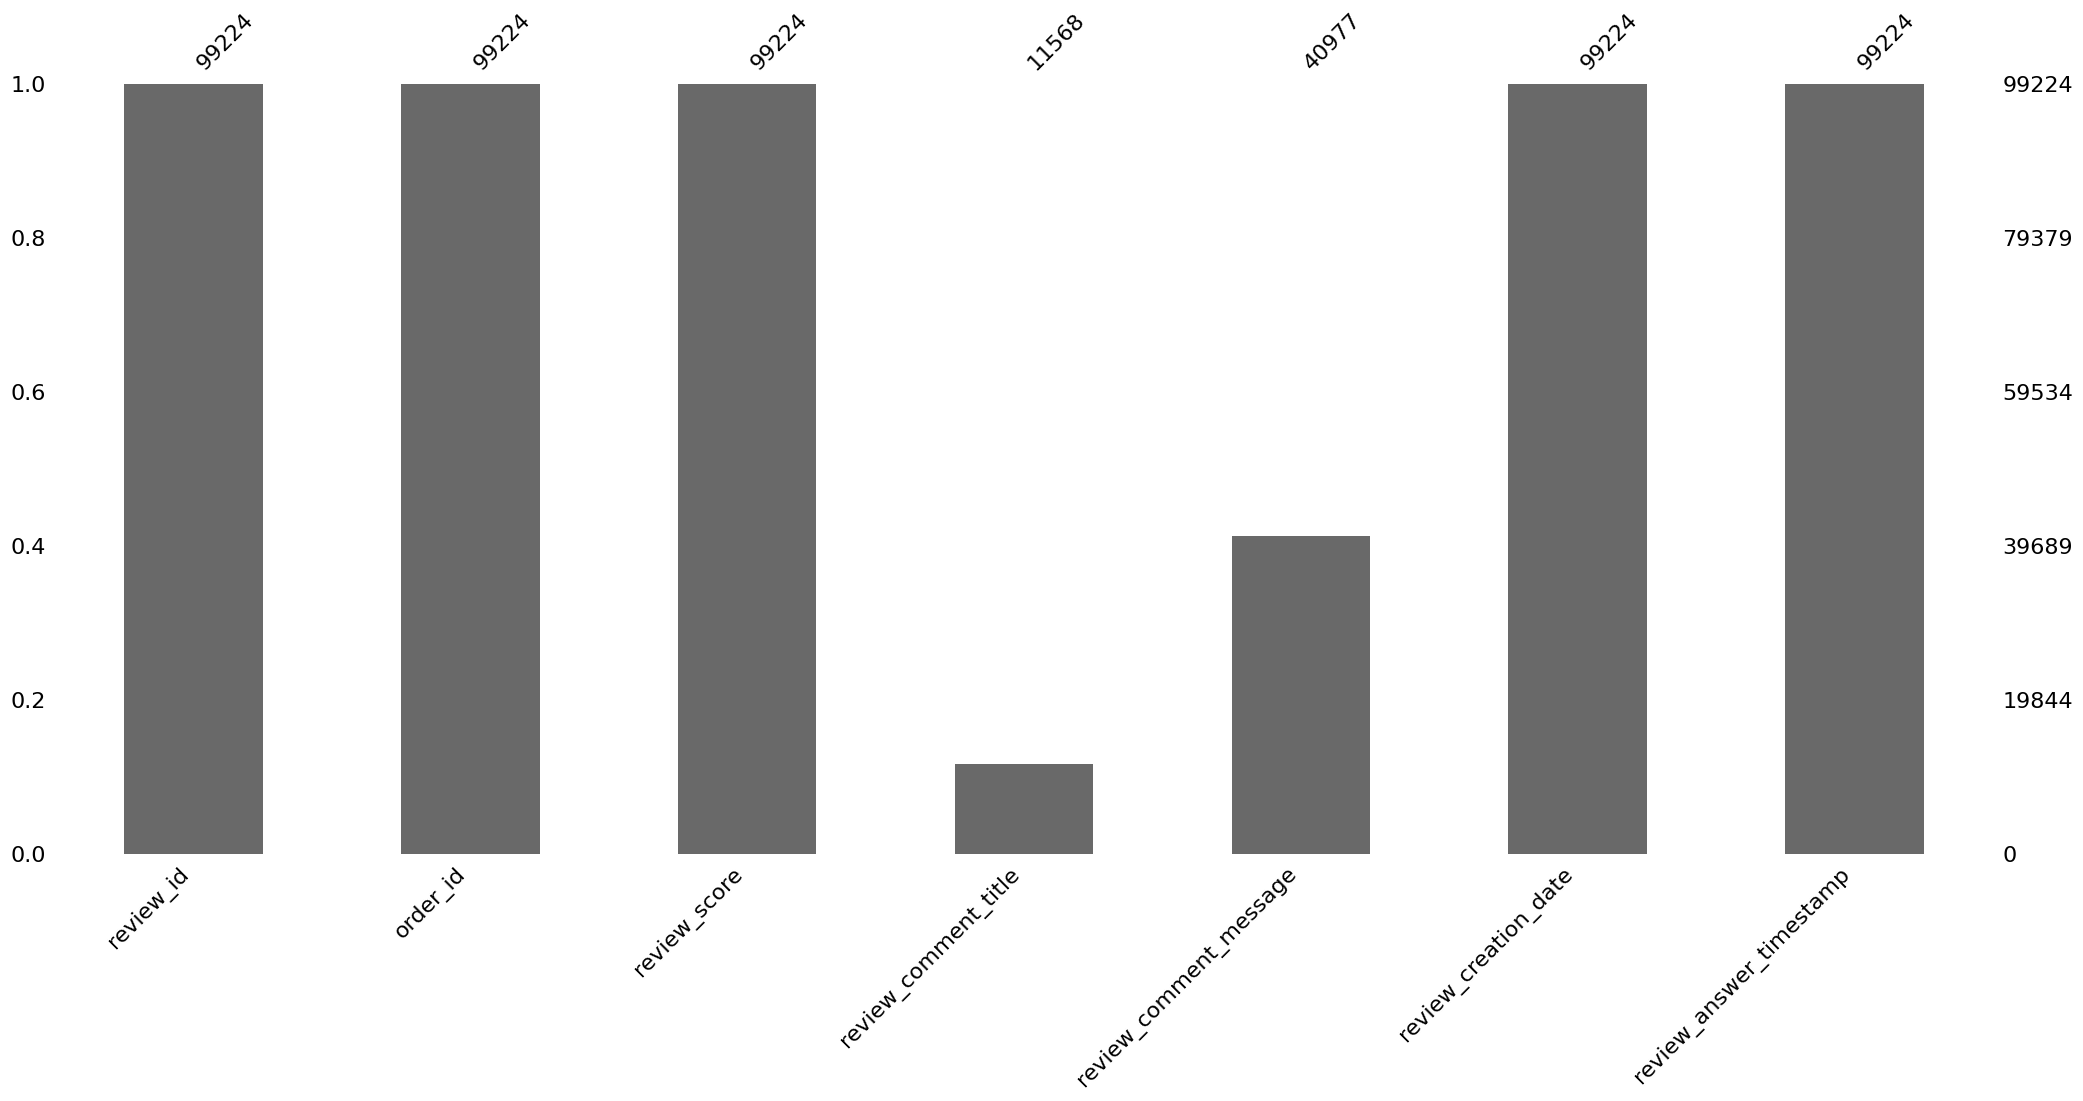


 ----> products 



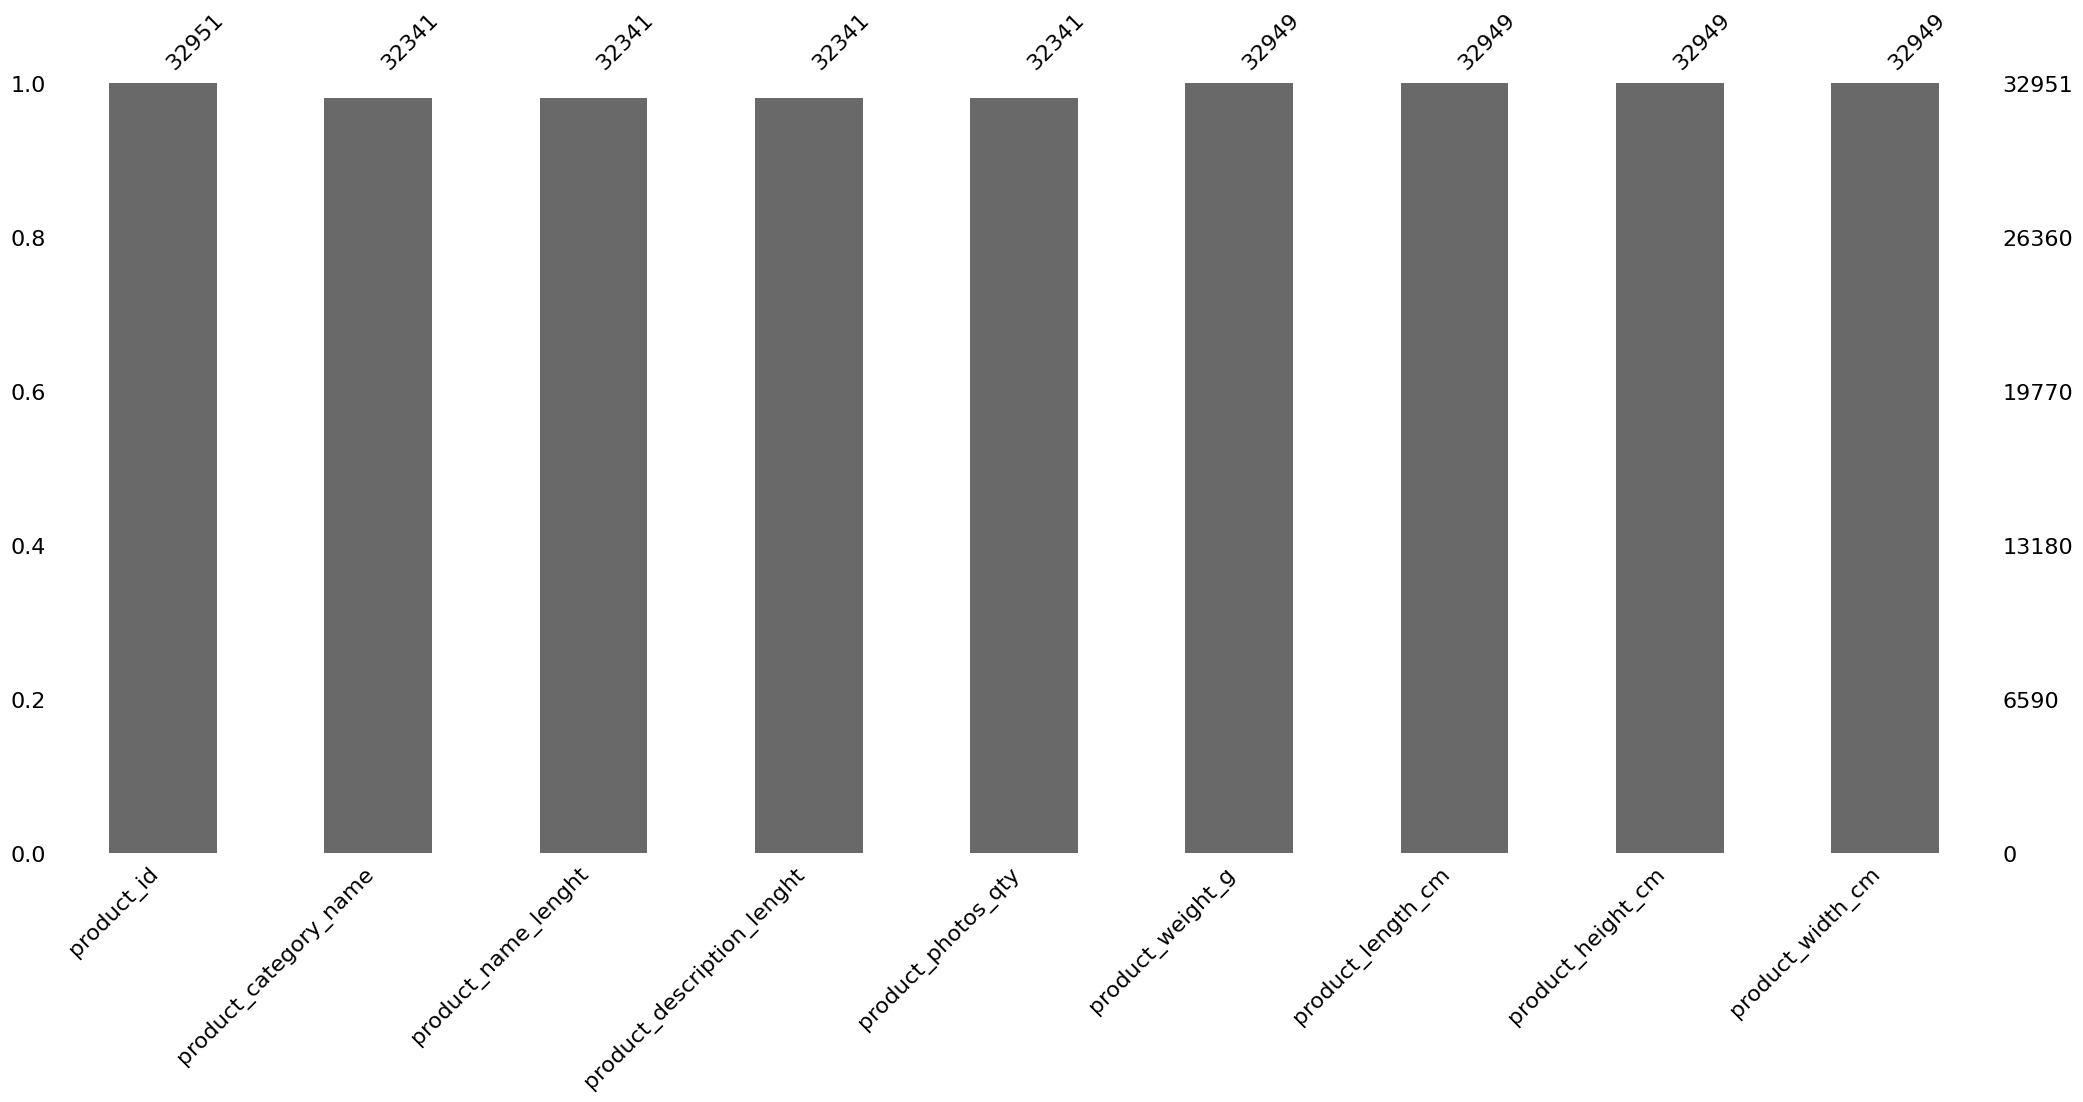


 ----> sellers 



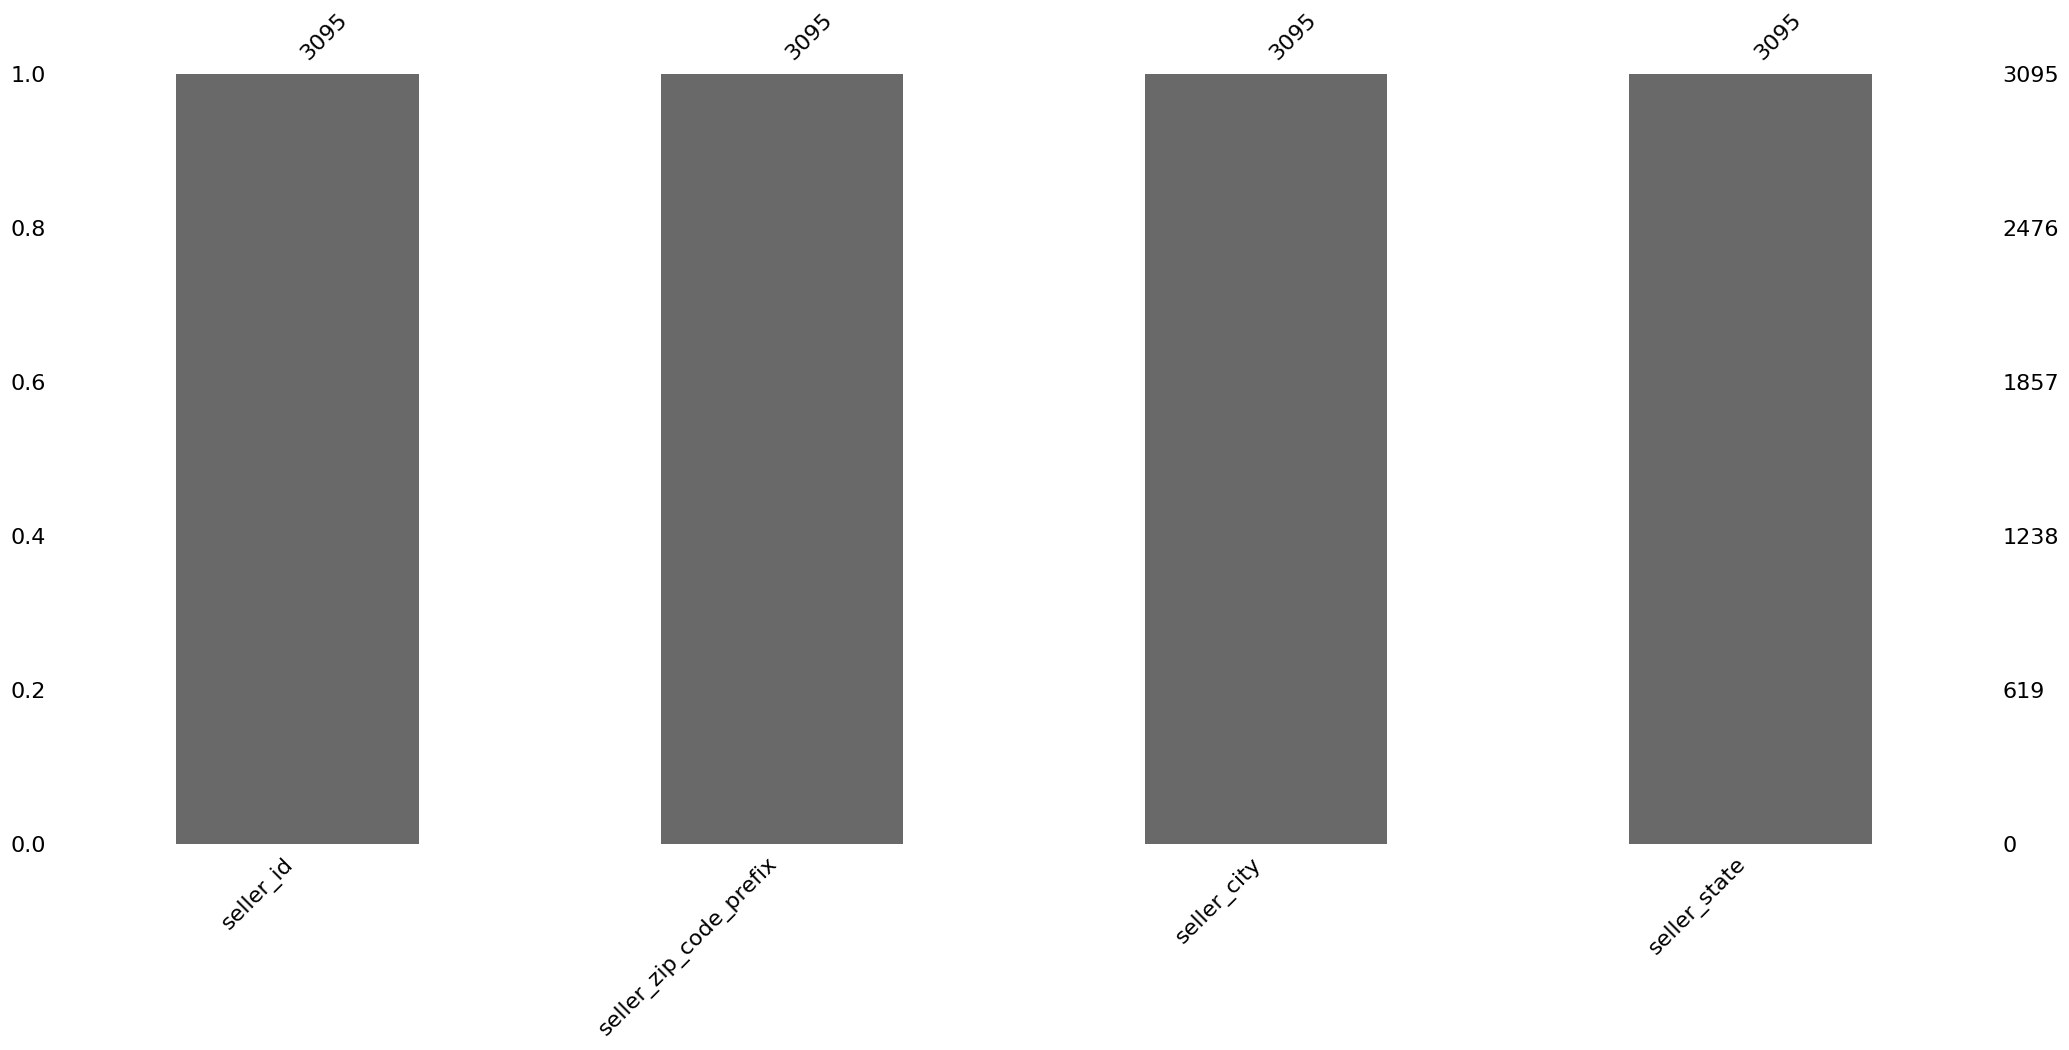


 ----> geolocation 



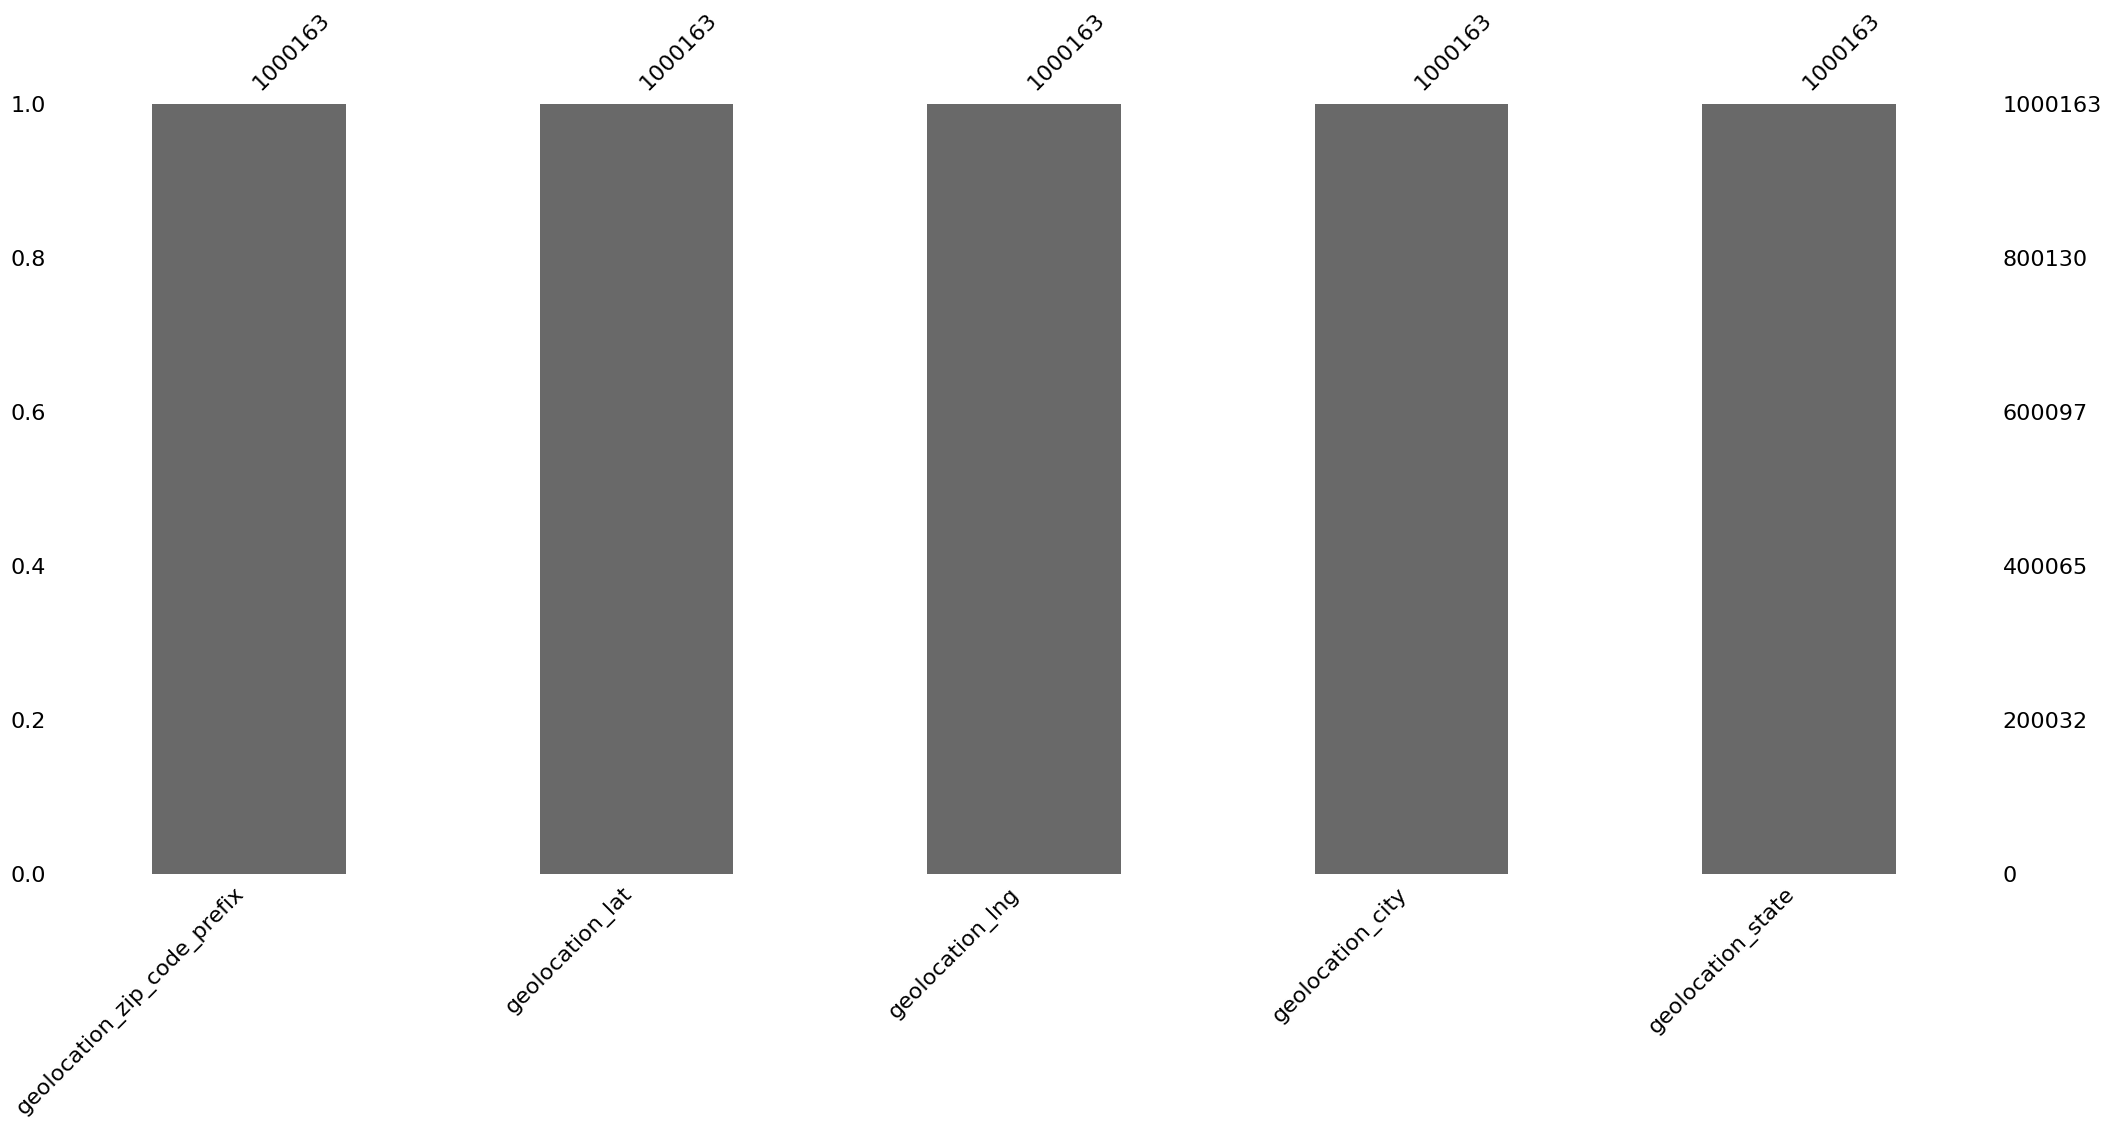


 ----> categories 



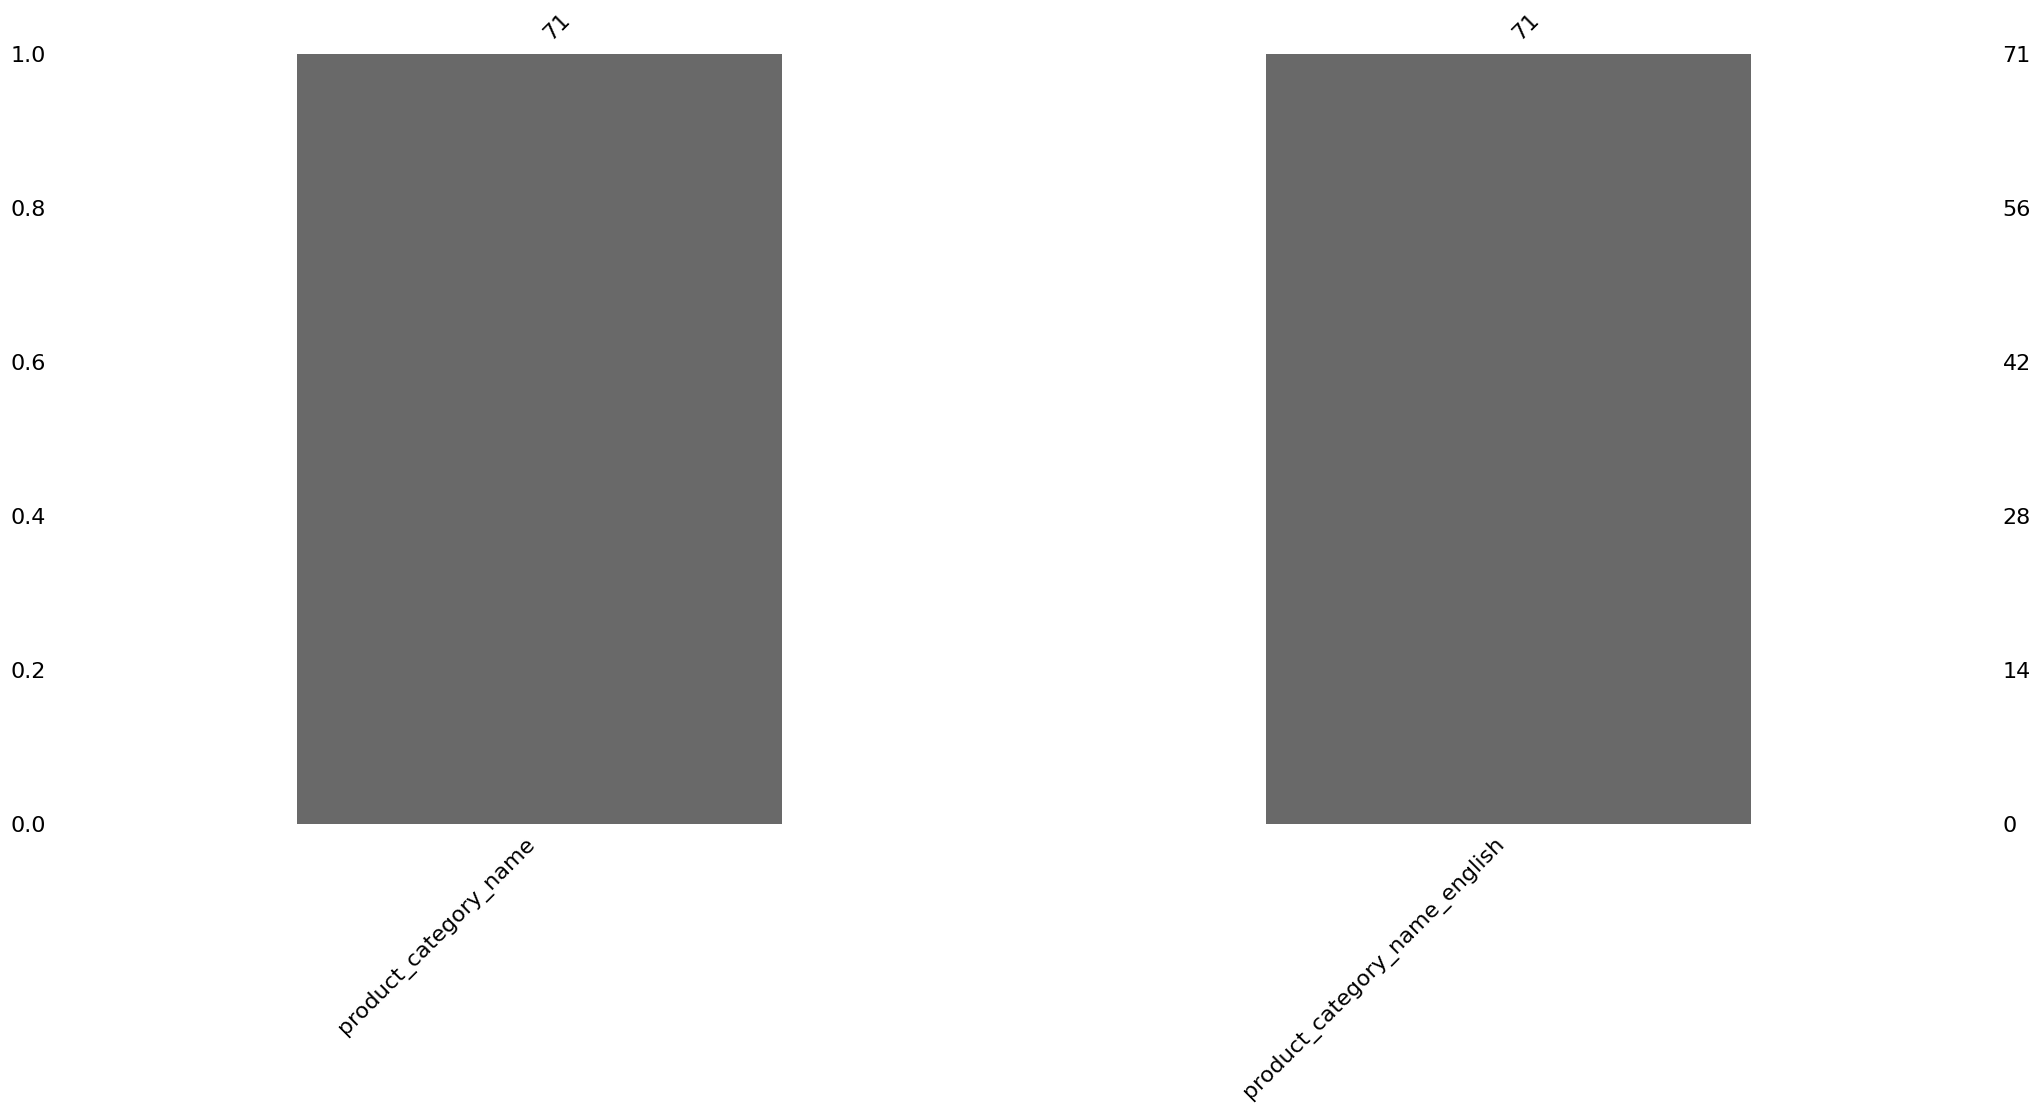

In [ ]:
for name, df in datasets.items():
    print("\n ---->", name,"\n")
    msno.bar(df)
    plt.show()


**Observación**:
- Dataset reviews:
 podemos observar que en las columnas *review_coment_title* y *review_comment_message* tienen una gran cantidad de valores faltantes
- Dataset orders:
Al tratarse de fechas se puede conciderar tecnicas de imputacion para llenar los faltantes despues de tratar los datos con las respectivas conversiones.
- Dataset products:
Se podria conciderar eliminar las filas de *product_category* name, ya que si se decidiera rellenar **no sabremos realmente a que categoria pertenece** y **alterariamos el resultado del analisis**.Al momento de la limpieza se recomienda verificar que se encuentren en las mismas filas las siguientes columnas:

  *   *product_name_lenght*
  *   *product_description_lenght*
  *   *product_photos_qty*

**En las siguientes columnas se recomienda imputar ya que solo se trata de 2 valores faltantes en cada una**.




# 10.Duplicados

En esta seccion se verifica la existencia de registros duplicados dentro de los datasets, ya que estos pueden generar sesgos en el análisis.

In [ ]:
for name, df in datasets.items():
    print("*" , name,"tiene", "duplicados:", df.duplicated().sum())

* customers tiene duplicados: 0
* orders tiene duplicados: 0
* order_items tiene duplicados: 0
* payments tiene duplicados: 0
* reviews tiene duplicados: 0
* products tiene duplicados: 0
* sellers tiene duplicados: 0
* geolocation tiene duplicados: 261831
* categories tiene duplicados: 0


**Observaciones**:

La tabla de geolocalización contiene 261.831 filas duplicadas exactas. Además, un análisis más detallado revela que un mismo prefijo de código postal puede tener múltiples coordenadas de latitud y longitud diferentes, ya que un prefijo representa un área geográfica, no un punto específico.


Por lo que para usar esta tabla  sin generar problemas durante las uniones SQL, debemos agregar los datos de manera que cada prefijo de código postal se convierta en una clave primaria única (por ejemplo, conservando la primera aparición o calculando el promedio de las coordenadas).

# 11.Distribución de variables

Esto nos permite comprender cómo se comportan las variables dentro del dataset.


--------------------------------------------------
DISTRIBUCIONES: ORDER_ITEMS
--------------------------------------------------


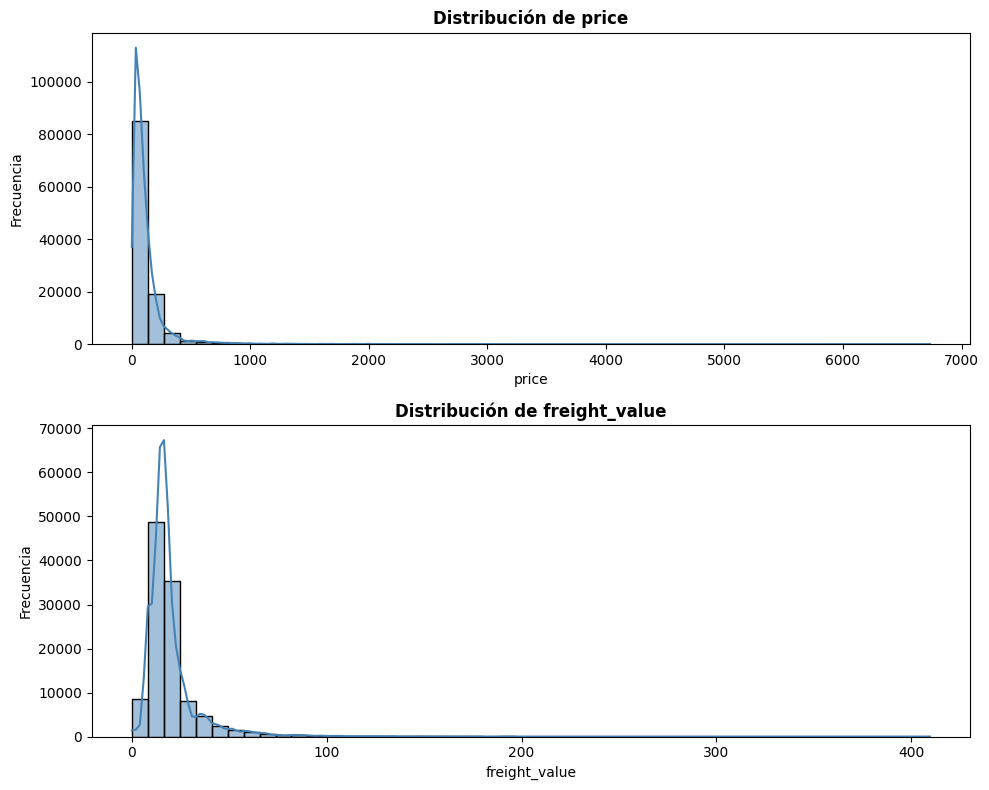


--------------------------------------------------
DISTRIBUCIONES: PAYMENTS
--------------------------------------------------


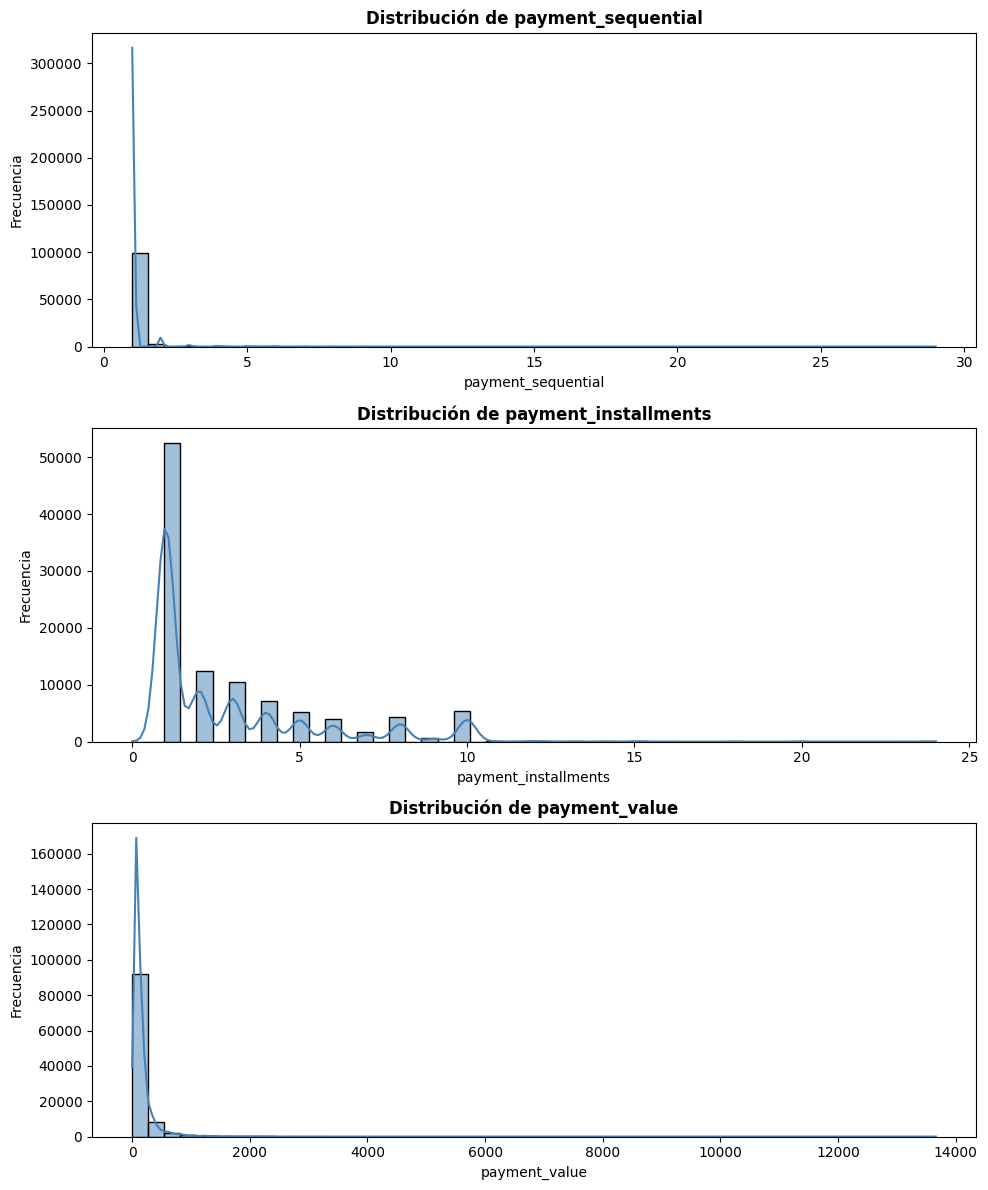


--------------------------------------------------
DISTRIBUCIONES: REVIEWS
--------------------------------------------------


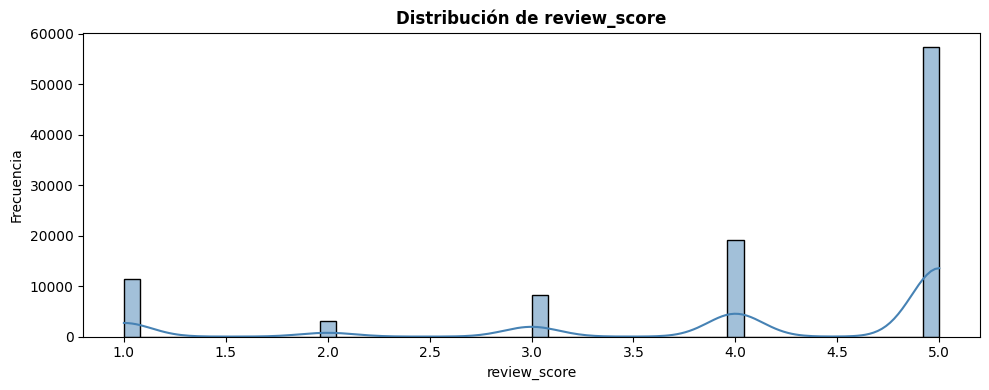


--------------------------------------------------
DISTRIBUCIONES: PRODUCTS
--------------------------------------------------


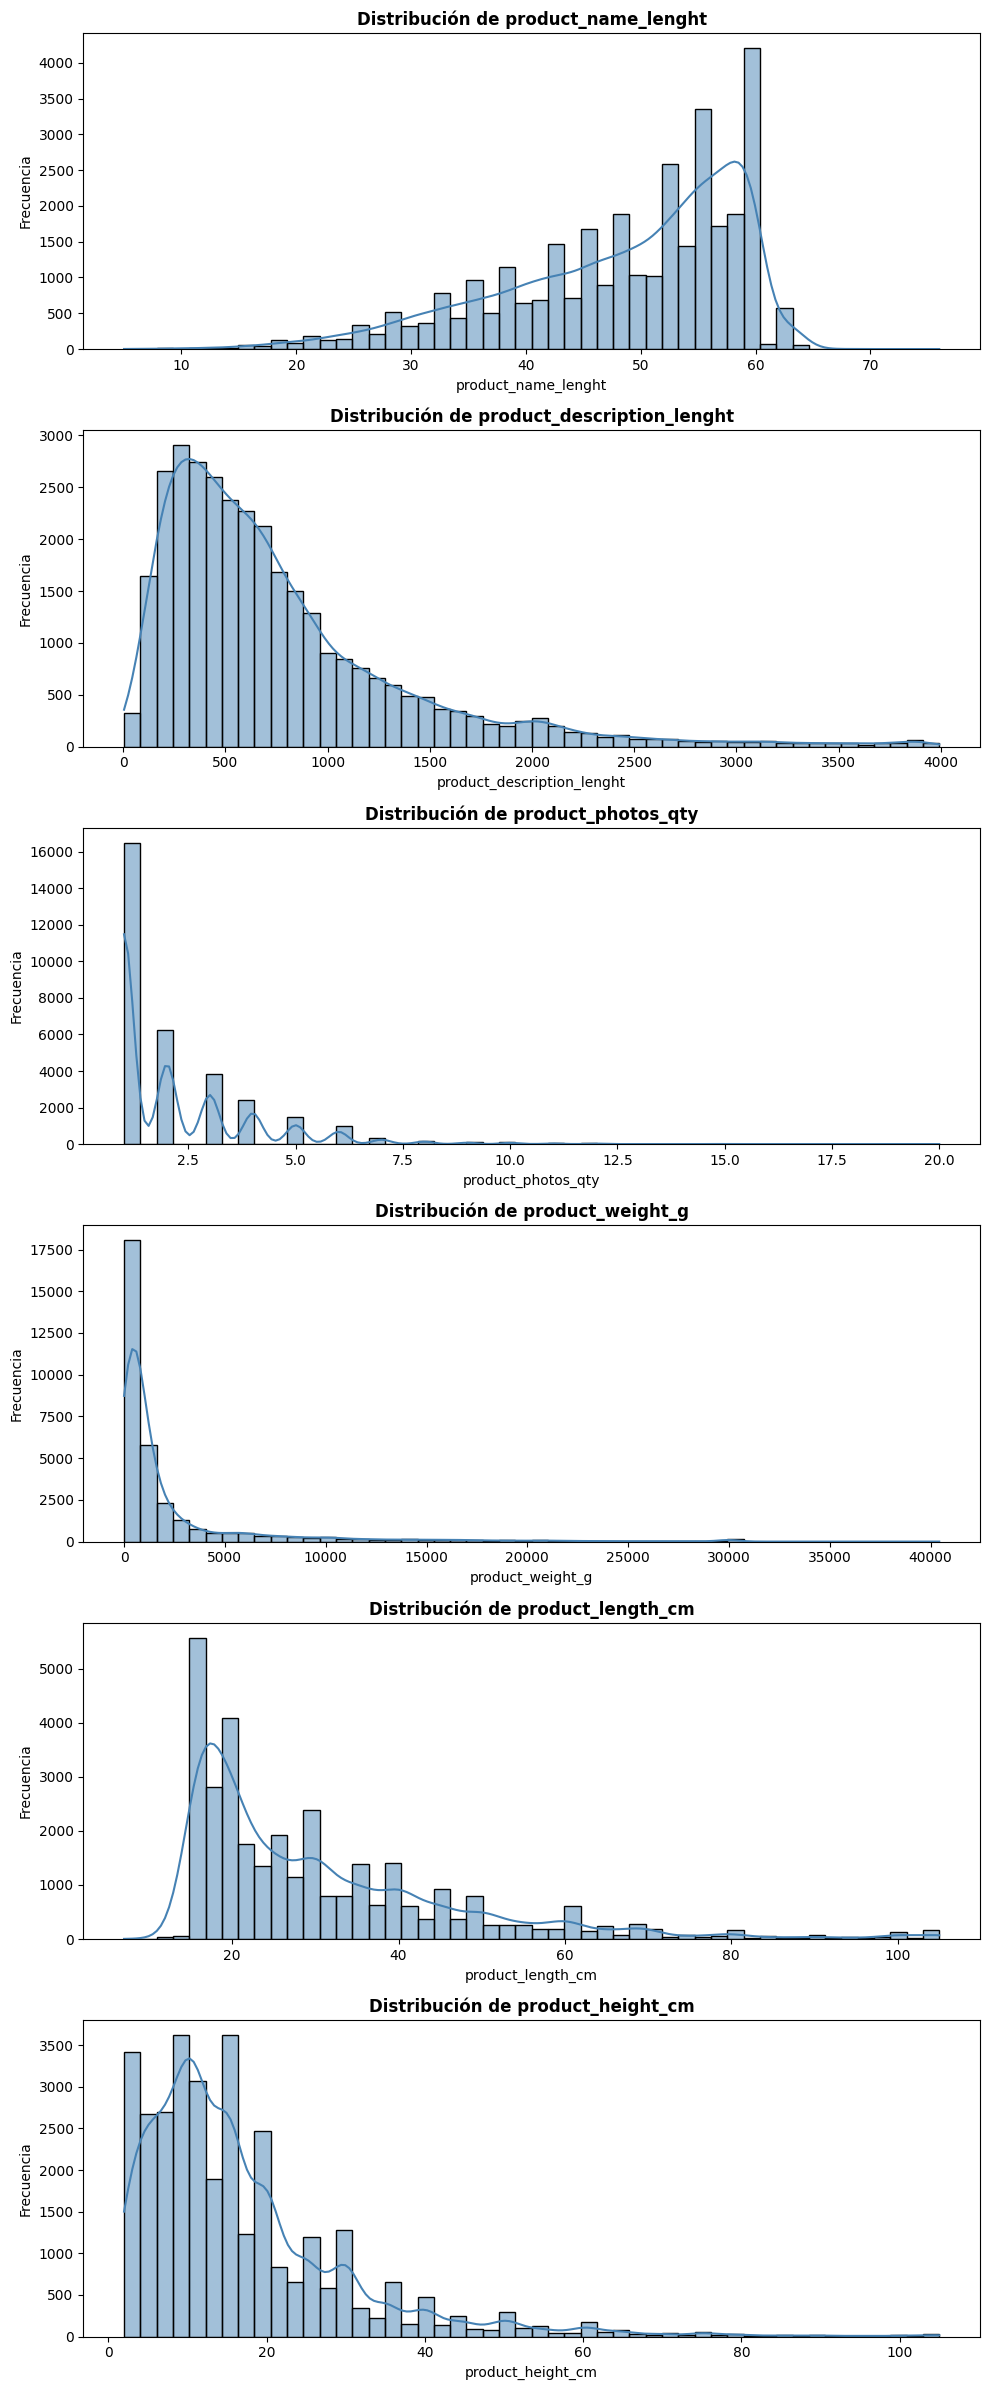


--------------------------------------------------
DISTRIBUCIONES: GEOLOCATION
--------------------------------------------------


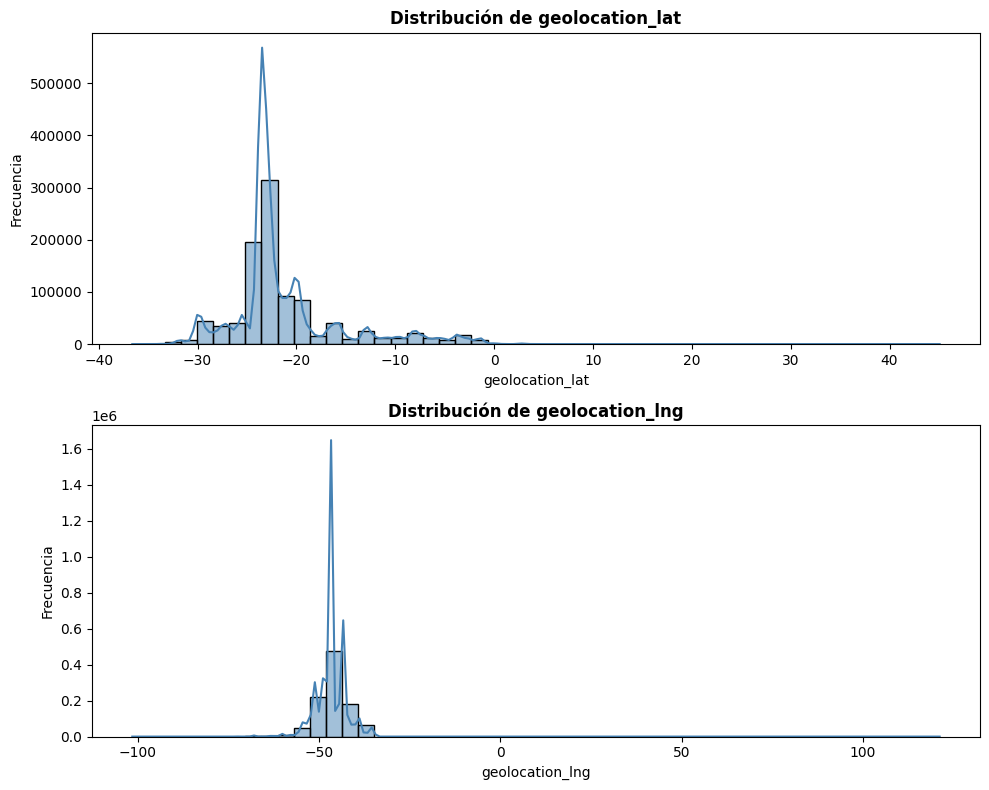

In [ ]:
for df_name, df in datasets.items():
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cols_to_plot = [col for col in num_cols if 'id' not in col.lower() and 'zip' not in col.lower()]

    if len(cols_to_plot) > 0:
        print(f"\n{'-'*50}")
        print(f"DISTRIBUCIONES: {df_name.upper()}")
        print(f"{'-'*50}")

        # tamaño de la figura dependiendo de los graficos
        fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(10, 4 * len(cols_to_plot)))

        # Si solo hay una columna, 'axes' no es una lista
        if len(cols_to_plot) == 1:
            axes = [axes]

        # Graficamos cada columna
        for i, col in enumerate(cols_to_plot):
            sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[i], color='steelblue')
            axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Frecuencia')
            axes[i].set_xlabel(col)

        plt.tight_layout()
        plt.show()

**Observación**:

A partir de los histogramas generados para las variables numéricas se observa que varias de ellas presentan distribuciones asimétricas hacia la derecha, especialmente aquellas relacionadas con precios, pagos o valores monetarios.



# 12.Analisis de Atipicos


--------------------------------------------------
Analisis de atipicos : ORDER_ITEMS
--------------------------------------------------


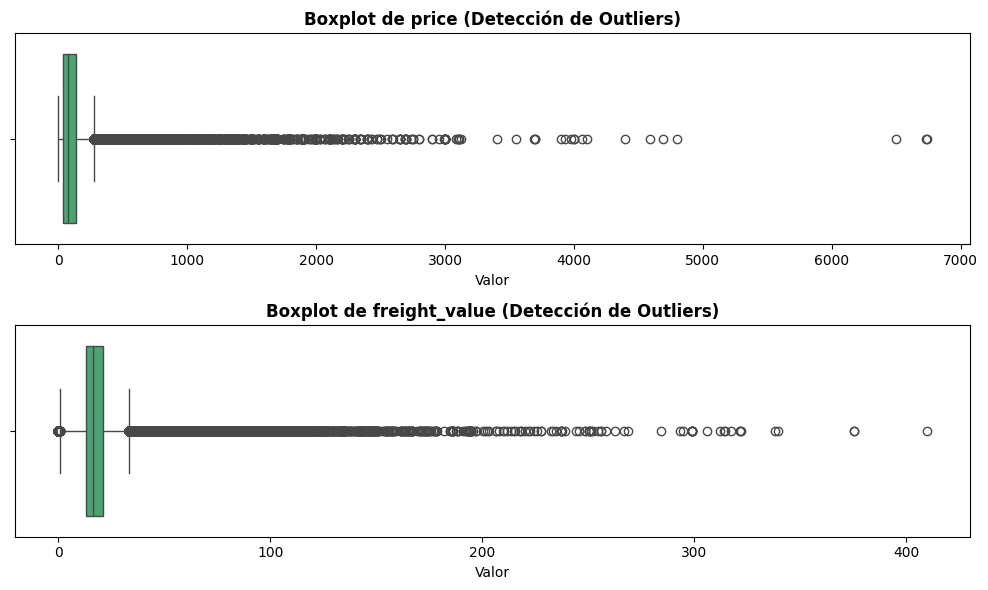


--------------------------------------------------
Analisis de atipicos : PAYMENTS
--------------------------------------------------


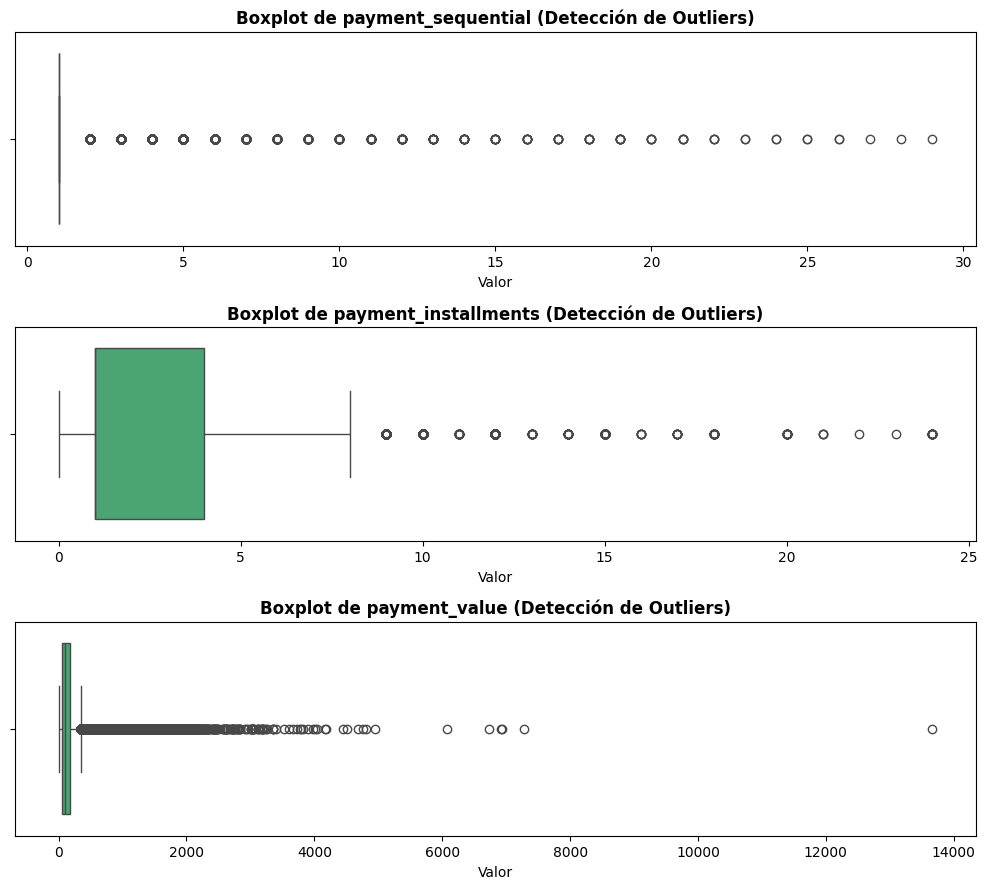


--------------------------------------------------
Analisis de atipicos : REVIEWS
--------------------------------------------------


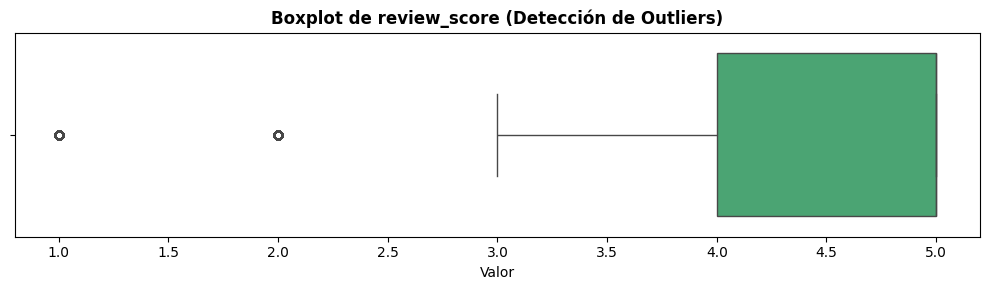


--------------------------------------------------
Analisis de atipicos : PRODUCTS
--------------------------------------------------


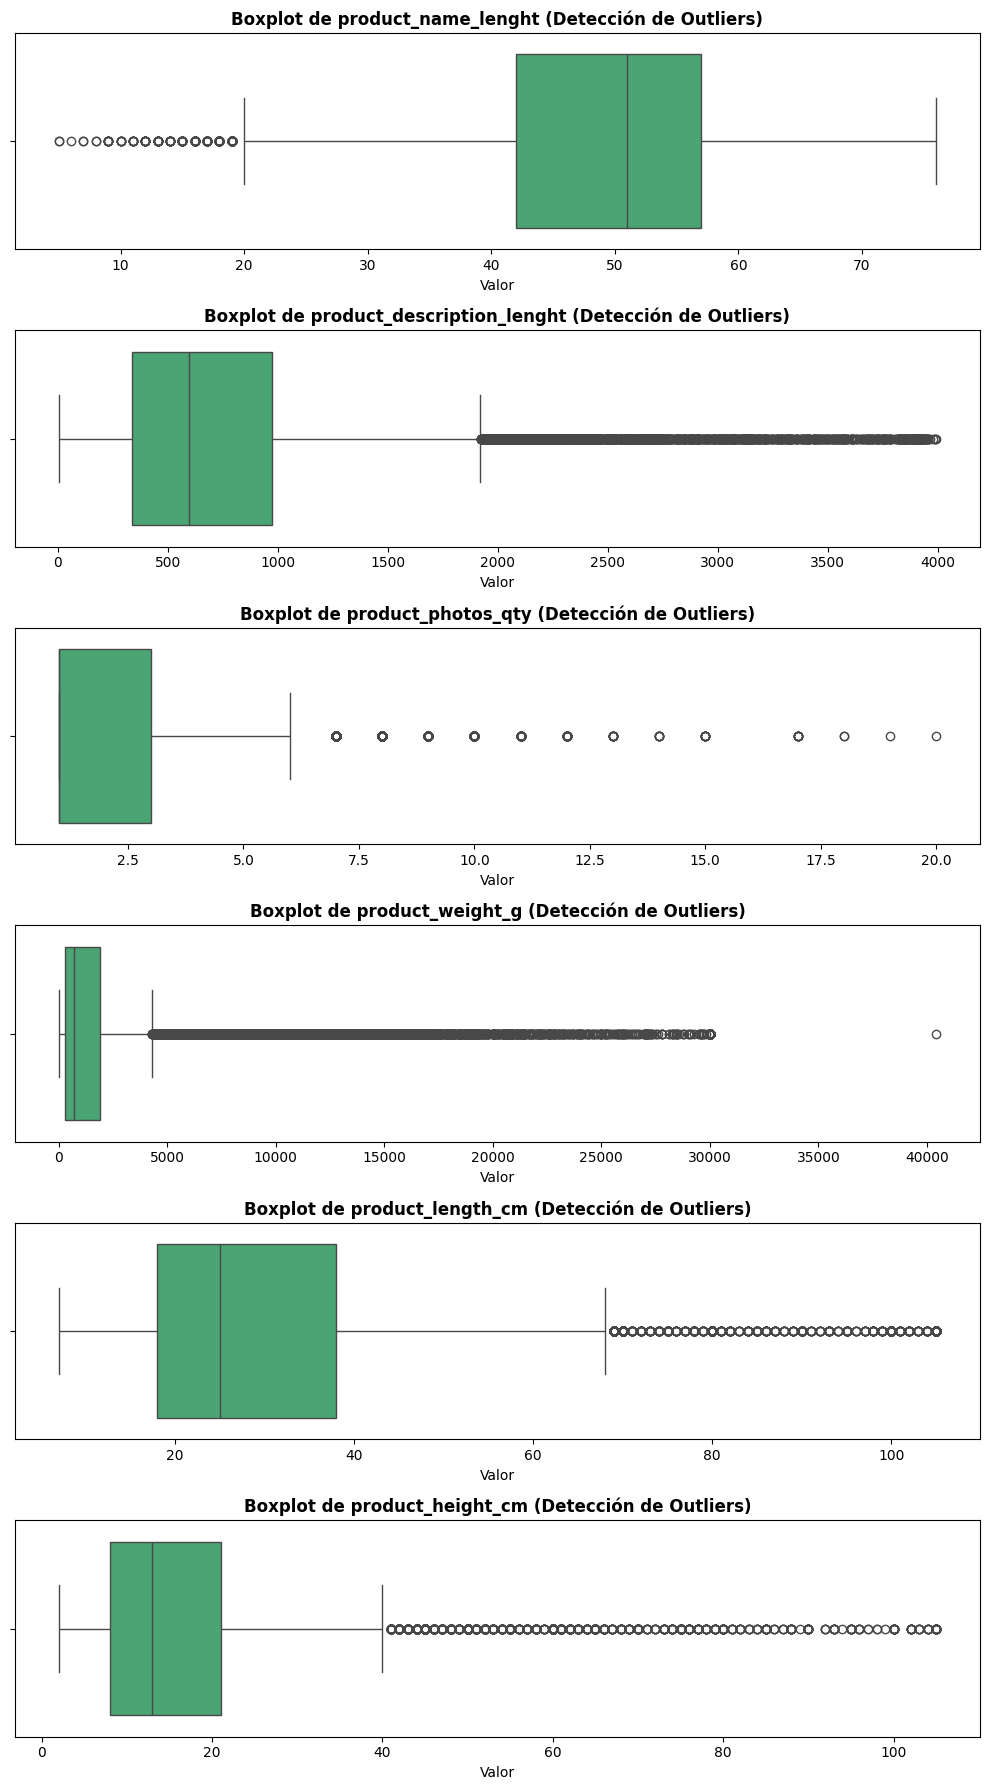


--------------------------------------------------
Analisis de atipicos : GEOLOCATION
--------------------------------------------------


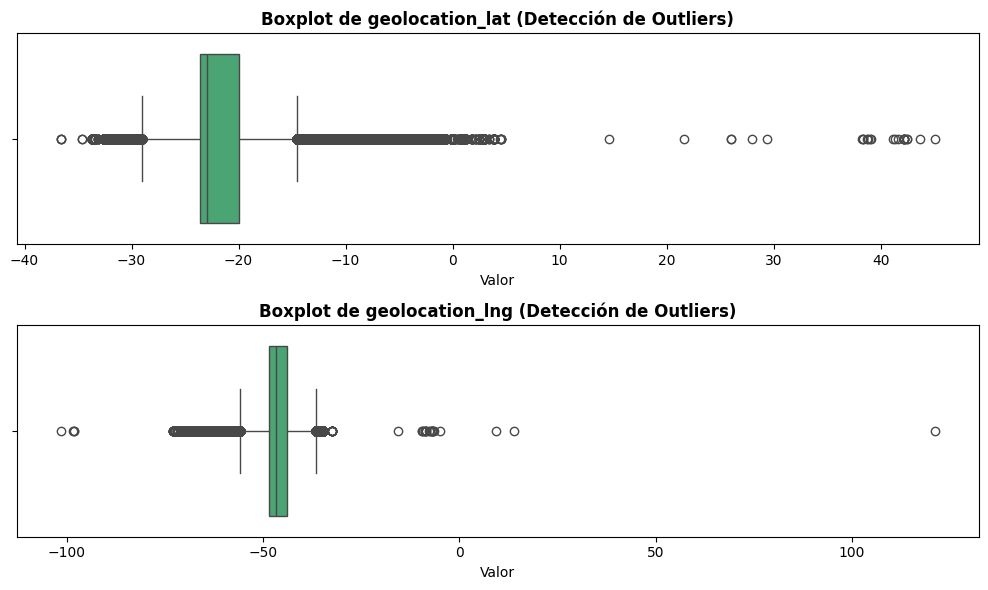

In [ ]:
for df_name, df in datasets.items():
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    # filtramos IDs y codigos postales
    cols_to_plot = [col for col in num_cols if 'id' not in col.lower() and 'zip' not in col.lower()]
    if len(cols_to_plot) > 0:
        print(f"\n{'-'*50}")
        print(f"Analisis de atipicos : {df_name.upper()}")
        print(f"{'-'*50}")
        fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(10, 3 * len(cols_to_plot)))
        if len(cols_to_plot) == 1:
            axes = [axes]
        for i, col in enumerate(cols_to_plot):
            sns.boxplot(data=df, x=col, ax=axes[i], color='mediumseagreen')
            axes[i].set_title(f'Boxplot de {col} (Detección de Outliers)', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Valor')

        plt.tight_layout()
        plt.show()

**Observación**:

El análisis mediante diagramas de caja permite identificar la presencia de valores atípicos en varias variables numéricas. Estos valores extremos aparecen principalmente en variables relacionadas con precios, costos de envío y montos de pago.

Estos valores no necesariamente representan errores en los datos, pero deben ser considerados durante el análisis posterior, especialmente en modelos estadísticos o de machine learning, ya que pueden afectar métricas como la media o la varianza.


# 13.Distribucion de precios

En esta parte se analiza la distribución de los precios de los productos vendidos en la plataforma.Esto nos permite comprender el comportamiento en las ventas y detectar posibles anomalias en los datos

In [ ]:
order_items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


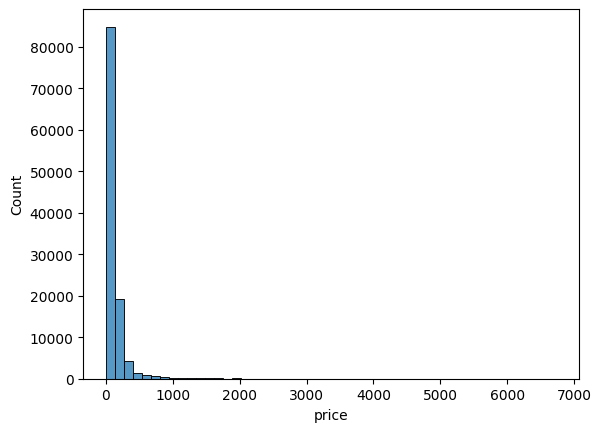

In [ ]:
sns.histplot(order_items['price'], bins=50)
plt.show()

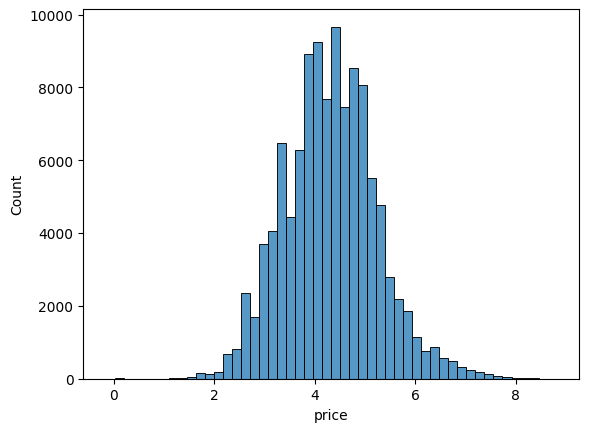

In [ ]:
sns.histplot(np.log(order_items['price']), bins=50)
plt.show()

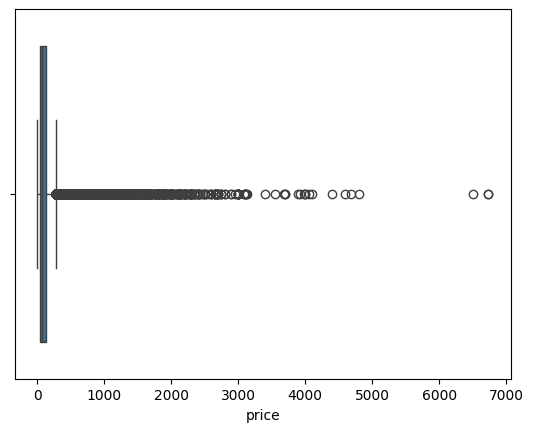

In [ ]:
sns.boxplot(x=order_items['price'])
plt.show()

**Observación**:

La distribución de precios **sesgada a la derecha** muestra que la mayoría de los productos se concentran dentro de un rango de precios bajos o medios.A demas el promedio es mucho mayor a la mediana, por lo que hay precios muy altos que empujan el promedio hacia arriba.

Tambien se puede apreciar en el diagrama de caja los valores atipicos o extremos , lo que indica la existencia de productos con precios significativamente altos al promedio.



# 14.Coincidencias entre tablas

Esto nos sirve para verificar si existen ordenes en **orders** cuyos clientes no estén en la tabla **customers** o si existen productos en **order_items** que no estén en la tabla **products**

In [ ]:
clientes_en_orders = orders['customer_id'].nunique()
clientes_en_ = customers['customer_id'].nunique()
coincidencias = orders['customer_id'].isin(customers['customer_id']).sum()

print(f"Total órdenes: {len(orders)}")
print(f"Órdenes con cliente válido: {coincidencias}")

Total órdenes: 99441
Órdenes con cliente válido: 99441


In [ ]:
productos_en_items = order_items['product_id'].nunique()
productos_en_products = products['product_id'].nunique()
coincidencias_productos = order_items['product_id'].isin(products['product_id']).sum()

print(f"Total items vendidos: {len(order_items)}")
print(f"Items con producto válido: {coincidencias_productos}")

Total items vendidos: 112650
Items con producto válido: 112650


**Observación**:

Con esto se verifica la integridad que se tiene entre las diferentes tablas.


# 15.Correlación

## Dataset: order_items

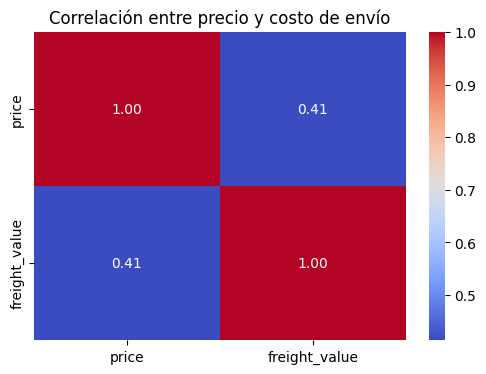

In [ ]:
corr_items = order_items[['price','freight_value']].corr(method='pearson')

plt.figure(figsize=(6,4))
sns.heatmap(corr_items, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre precio y costo de envío")
plt.show()

**Observación**:

La correlación entre el precio del producto y el costo de envío es moderada (0.41) lo que nos dice que los productos más costosos tienden a tener costos de envío más altos.

Pero de todas maneras, al no tener una correlacion fuerte indica que el costo de envío tanbién depende de otros factores como el peso, la distancia del envío,etc.

## Dataset : order_payments

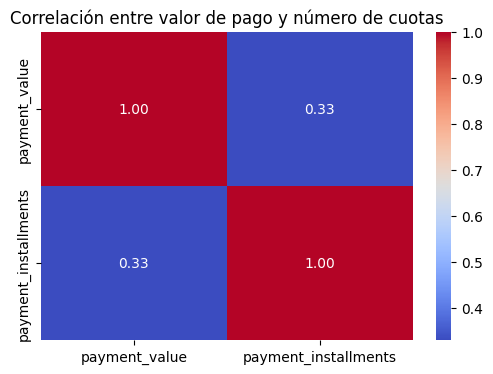

In [ ]:
corr_payments = payments[['payment_value','payment_installments']].corr(method='pearson')

plt.figure(figsize=(6,4))
sns.heatmap(corr_payments, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre valor de pago y número de cuotas")
plt.show()

**Observación**:

Al ser una correlación positiva pero debil(0.33), nos indica que pedidos con valores más altos tienden ocacionalmente a pagarse en más cuotas.Sin embargo, el uso de cuotas depende también de otras preferencias del cliente u otros pagos disponibles.

## Correlación entre tablas

In [ ]:
merged_df = order_items.merge(payments, on='order_id')
merged_df = merged_df.merge(reviews, on='order_id')

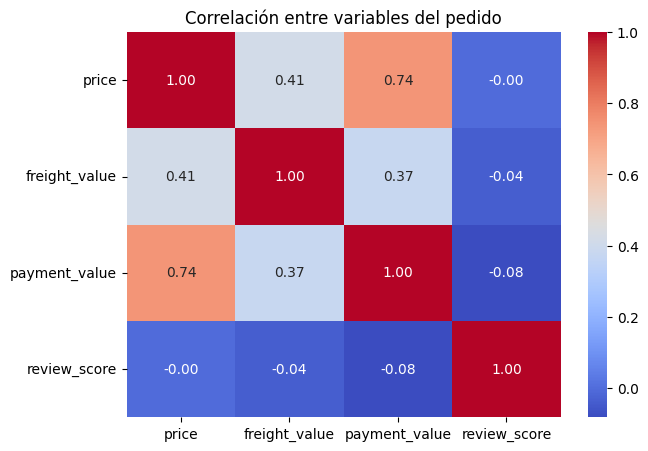

In [ ]:
corr_total = merged_df[['price','freight_value','payment_value','review_score']].corr(method='pearson')

plt.figure(figsize=(7,5))
sns.heatmap(corr_total, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre variables del pedido")
plt.show()


**Observación**:

En el análisis de correlación muestra una relación fuerte(0.74) entre *price* y el valor total del pago *payment_value*.Esto es evidente,ya que el monto pagado depende directamente del precio del producto.

Tambien se observa una correlacion moderada entre el costo de envío *freight_value* y el precio del producto,tambien como entre el costo de envío y el valor del pago

Por otro lado,la puntuación de reseñas *review_score* presenta una correlación cercana a cero con las variables monetarias, lo que significa que la satisfacción del cliente no está directamente relacionada con el precio del producto o el costo del envío.

## Diagrama de dispersión entre producto y valor de pago

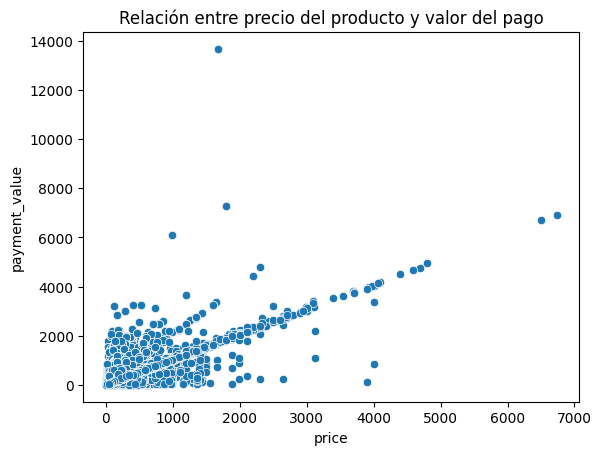

In [ ]:
sns.scatterplot(data=merged_df, x='price', y='payment_value')
plt.title("Relación entre precio del producto y valor del pago")
plt.show()

**Observación**:

Este diagrama de dispersión entre precio del producto y el valor del pago muestra una clara tendencia positiva,donde pedidos con precios más altos generalmente corresponden a valores de pago mayores.También se observan algunos valores extremos, correspondientes a pedidos de alto valor.





# 16.Análisis de fechas

Esto permite comprender el comportamiento de los pedidos a lo largo del timpo, como:
  * Frecuencia de pedidos
  * Tiempos de entrega
  * Evolución de las ventas

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_purchase_timestamp'].describe()

,order_purchase_timestamp
count,99441
mean,2017-12-31 08:43:12.776581120
min,2016-09-04 21:15:19
25%,2017-09-12 14:46:19
50%,2018-01-18 23:04:36
75%,2018-05-04 15:42:16
max,2018-10-17 17:30:18


**Observación**:

Una vez que se complete la transformación adecuada de los datos temporales, se podra identificar los periodos con mayor actividad de compras,por lo cual estas variables estan relacionadas con temporadas comerciales, promociones o eventos especiales.

# 17.Diagnostico Final

Después de realizar el análisis exploratorio de datos, se identificaron varios aspectos relevantes que deben considerarse durante la fase de **limpieza** y preparación de los datos:

  * Existen **valores nulos** en algunas columnas, especialmente en información relacionada con productos y reseñas,los cuales deben evaluarse para decidir si se eliminan, imputan o se mantienen según el contexto del análisis.
  * Varias variables de tipo fecha requieren conversión al formato datetime, lo cual permitirá realizar análisis temporales adecuados, como tendencias de pedidos o tiempos de entrega.

  * Se detectaron inconsistencias en algunos nombres de columnas, como errores tipográficos.
  
  *  Se identificó la posible presencia de valores atípicos en variables numéricas, particularmente en precios, pero debe evaluarse y considerarse para evitar sesgos en el análisis.

  * Algunas variables de fecha requieren conversión al formato datetime para permitir análisis temporales adecuados.

  * El análisis de correlación mostró relaciones positivas entre **variables monetarias**, especialmente entre el precio del producto y el valor del pago, mientras que las puntuaciones de reseñas no presentan una relación significativa con estas variables.

El dataset requiere procesos de limpieza y transformación antes de ser utilizado en análisis más avanzados.